# SIV Project

In [ ]:
import urllib.request
import pandas as pd

df = pd.read_csv("Dataset/dataset.csv")
print(f"Dataset loaded! Shape: {df.shape}")

Dataset caricato! Shape: (4794, 102)


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn opencv-python mediapipe 

## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading

In [4]:
DATA_PATH = "Dataset/dataset.csv"
df = pd.read_csv(DATA_PATH)

## Landmark Selection

In [ ]:
selected_columns = [
    "subject",
    "upperbody_label",
    "nose_x", "nose_y", "nose_z",
    "left_eye_x", "left_eye_y", "left_eye_z",
    "right_eye_x", "right_eye_y", "right_eye_z",
    "left_ear_x", "left_ear_y", "left_ear_z",
    "right_ear_x", "right_ear_y", "right_ear_z",
    "left_shoulder_x", "left_shoulder_y", "left_shoulder_z",
    "right_shoulder_x", "right_shoulder_y", "right_shoulder_z",
    "left_hip_x", "left_hip_y", "left_hip_z",
    "right_hip_x", "right_hip_y", "right_hip_z"
]

missing_cols = [col for col in selected_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Some columns are missing from the dataset: {missing_cols}")

df_posture = df[selected_columns].copy()

print("Selected dataset shape:", df_posture.shape)
print("Total missing values:", df_posture.isnull().sum().sum())

nose_y_med = df_posture["nose_y"].median()
hip_y_med  = ((df_posture["left_hip_y"] + df_posture["right_hip_y"]) / 2).median()
pct_neg_y  = (df_posture["nose_y"] < 0).mean()

print(f"\n── Coordinate system check ──")
print(f"  nose_y median   : {nose_y_med:.4f}  (expected world: ~-0.45 / -0.55)")
print(f"  hip_y  median   : {hip_y_med:.4f}   (expected world: ~0.0)")
print(f"  nose_y < 0      : {pct_neg_y:.1%}  (expected world: >90%)")

if pct_neg_y > 0.80 and nose_y_med < -0.20:
    print("  ✓ World coordinates confirmed — consistent with pose_world_landmarks")
else:
   raise ValueError(
    "Wrong coordinate system: y values look like image coords (0-1 range, mostly positive).\n"
    "Expected world coords from pose_world_landmarks (negative y for upper body).\n"
    "Double-check how the CSV was exported."
)

Selected dataset shape: (4794, 29)
Total missing values: 0

── Coordinate system check ──
  nose_y mediana  : -0.4870  (world atteso: ~-0.45 / -0.55)
  hip_y  mediana  : -0.0016   (world atteso: ~0.0)
  nose_y < 0      : 98.4%  (world atteso: >90%)
  ✓ World coordinates confermato — compatibile con pose_world_landmarks


## Midpoint Construction

In [6]:
# Thresholds for future consistency with the real-time pipeline
HEAD_Z_CONF_THR = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR = 0.6


# Compute the midpoint between two bilateral landmarks
def add_midpoint(df, left_prefix, right_prefix, out_prefix):
    # Check whether all coordinates are available for the left landmark
    left_available = df[
        [f"{left_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # Check whether all coordinates are available for the right landmark
    right_available = df[
        [f"{right_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # The midpoint is available only when both landmarks are present
    available = left_available & right_available

    # Compute midpoint coordinates for each axis
    for axis in ["x", "y", "z"]:
        midpoint = (df[f"{left_prefix}_{axis}"] + df[f"{right_prefix}_{axis}"]) / 2
        df[f"{out_prefix}_{axis}"] = np.where(available, midpoint, np.nan)

    # Store binary availability information
    df[f"{out_prefix}_available"] = available

    # Store binary confidence information
    # The offline dataset does not provide continuous visibility scores
    df[f"{out_prefix}_conf"] = available.astype(float)

    return df


# Compute bilateral midpoints used for posture representation
df_posture = add_midpoint(df_posture, "left_shoulder", "right_shoulder", "mid_shoulder")
df_posture = add_midpoint(df_posture, "left_hip", "right_hip", "mid_hip")
df_posture = add_midpoint(df_posture, "left_ear", "right_ear", "mid_ear")
df_posture = add_midpoint(df_posture, "left_eye", "right_eye", "mid_eye")


# Define reliability flags for the main structural midpoints
df_posture["mid_shoulder_reliable"] = df_posture["mid_shoulder_available"]
df_posture["mid_hip_reliable"] = df_posture["mid_hip_available"]


# Check availability of candidate landmarks for head center construction
eye_available = df_posture[
    [
        "left_eye_x", "left_eye_y", "left_eye_z",
        "right_eye_x", "right_eye_y", "right_eye_z"
    ]
].notna().all(axis=1)

ear_available = df_posture[
    [
        "left_ear_x", "left_ear_y", "left_ear_z",
        "right_ear_x", "right_ear_y", "right_ear_z"
    ]
].notna().all(axis=1)

nose_available = df_posture[
    ["nose_x", "nose_y", "nose_z"]
].notna().all(axis=1)


# Construct head center coordinates using a hierarchical fallback strategy
# Priority: mid-eye -> mid-ear -> nose
for axis in ["x", "y", "z"]:
    df_posture[f"head_center_{axis}"] = np.where(
        eye_available,
        df_posture[f"mid_eye_{axis}"],
        np.where(
            ear_available,
            df_posture[f"mid_ear_{axis}"],
            np.where(
                nose_available,
                df_posture[f"nose_{axis}"],
                np.nan
            )
        )
    )


# Track which landmark source was used for head center construction
df_posture["head_center_source"] = np.where(
    eye_available,
    "mid_eye",
    np.where(
        ear_available,
        "mid_ear",
        np.where(nose_available, "nose", "missing")
    )
)


# Store availability and binary confidence for head center
df_posture["head_center_available"] = (
    eye_available |
    ear_available |
    nose_available
)

# The offline dataset uses binary confidence only
df_posture["head_center_conf"] = df_posture["head_center_available"].astype(float)


# Define z-axis reliability flags
# Depth is considered more reliable when head center comes from bilateral landmarks
df_posture["head_center_z_reliable"] = df_posture["head_center_source"].isin(
    ["mid_eye", "mid_ear"]
)

# Upper-body depth is reliable only if both head center and shoulder midpoint are reliable
df_posture["upper_z_reliable"] = (
    df_posture["head_center_z_reliable"] &
    df_posture["mid_shoulder_reliable"]
)


# Quick inspection of the generated midpoint and reliability features
print(
    df_posture[
        [
            "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
            "mid_shoulder_available", "mid_shoulder_conf", "mid_shoulder_reliable",

            "mid_hip_x", "mid_hip_y", "mid_hip_z",
            "mid_hip_available", "mid_hip_conf", "mid_hip_reliable",

            "mid_ear_x", "mid_ear_y", "mid_ear_z",
            "mid_ear_available", "mid_ear_conf",

            "mid_eye_x", "mid_eye_y", "mid_eye_z",
            "mid_eye_available", "mid_eye_conf",

            "head_center_x", "head_center_y", "head_center_z",
            "head_center_source", "head_center_available", "head_center_conf",

            "head_center_z_reliable",
            "upper_z_reliable"
        ]
    ].head()
)

   mid_shoulder_x  mid_shoulder_y  mid_shoulder_z  mid_shoulder_available  \
0       -0.003340       -0.420315        0.080012                    True   
1       -0.024557       -0.402996        0.074528                    True   
2       -0.019990       -0.416819        0.079878                    True   
3       -0.018267       -0.421805        0.133939                    True   
4       -0.017067       -0.424594        0.114998                    True   

   mid_shoulder_conf  mid_shoulder_reliable  mid_hip_x  mid_hip_y  mid_hip_z  \
0                1.0                   True   0.001291  -0.000791   0.002073   
1                1.0                   True   0.001609  -0.000846   0.002505   
2                1.0                   True   0.001615  -0.000845   0.002508   
3                1.0                   True   0.001598  -0.000860   0.002347   
4                1.0                   True   0.001614  -0.000858   0.002423   

   mid_hip_available  ...  mid_eye_available  mid_eye_co

## Feature Definition

### Primary Features

In [ ]:
eps = 1e-6

# Wrap angle to [-90, 90)
def wrap_angle_90(angle_deg):
    return ((angle_deg + 90) % 180) - 90


# Signed angular difference in [-180, 180)
def angle_diff_deg(a, b):
    return (a - b + 180) % 360 - 180


# Required columns check
required_columns = [
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y",
    "left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y",
    "head_center_x", "head_center_y", "head_center_z",
    "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
    "upper_z_reliable"
]

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")


# =========================
# 1) SHOULDERS GEOMETRY
# =========================
dx_shoulder = df_posture["right_shoulder_x"] - df_posture["left_shoulder_x"]
dy_shoulder = df_posture["right_shoulder_y"] - df_posture["left_shoulder_y"]

df_posture["shoulder_slope"] = wrap_angle_90(
    np.degrees(np.arctan2(dy_shoulder, dx_shoulder))
)

df_posture["shoulder_width"] = np.hypot(dx_shoulder, dy_shoulder)
df_posture["shoulder_width"] = df_posture["shoulder_width"].replace(0, np.nan)
df_posture["shoulder_width_safe"] = df_posture["shoulder_width"].fillna(eps)

u_x = dx_shoulder / df_posture["shoulder_width_safe"]
u_y = dy_shoulder / df_posture["shoulder_width_safe"]

n_x = -u_y
n_y = u_x

# dot > 0 means n already points toward the head → no flip needed.
# dot < 0 means n points in the opposite direction → invert.
dot = n_x * (df_posture["nose_x"] - df_posture["mid_shoulder_x"]) + \
      n_y * (df_posture["nose_y"] - df_posture["mid_shoulder_y"])
flip_mask = dot < 0
n_x = np.where(flip_mask, -n_x, n_x)
n_y = np.where(flip_mask, -n_y, n_y)


# =========================
# 2) HEAD ORIENTATION
# =========================
eye_available = df_posture[
    ["left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y"]
].notna().all(axis=1)

ear_available = df_posture[
    ["left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y"]
].notna().all(axis=1)

dx_eye = df_posture["right_eye_x"] - df_posture["left_eye_x"]
dy_eye = df_posture["right_eye_y"] - df_posture["left_eye_y"]
head_tilt_eye = wrap_angle_90(np.degrees(np.arctan2(dy_eye, dx_eye)))

dx_ear = df_posture["right_ear_x"] - df_posture["left_ear_x"]
dy_ear = df_posture["right_ear_y"] - df_posture["left_ear_y"]
head_tilt_ear = wrap_angle_90(np.degrees(np.arctan2(dy_ear, dx_ear)))

df_posture["head_tilt"] = np.where(
    eye_available,
    head_tilt_eye,
    np.where(ear_available, head_tilt_ear, np.nan)
)


# =========================
# 3) HEAD RELATIVE TO SHOULDERS
# =========================
H_x = df_posture["head_center_x"] - df_posture["mid_shoulder_x"]
H_y = df_posture["head_center_y"] - df_posture["mid_shoulder_y"]
H_z = df_posture["head_center_z"] - df_posture["mid_shoulder_z"]

proj_shoulder_axis   = H_x * u_x + H_y * u_y
proj_shoulder_normal = H_x * n_x + H_y * n_y

df_posture["head_lateral_ratio"] = proj_shoulder_axis / df_posture["shoulder_width_safe"]

# FIX: negation to align convention with world coords
df_posture["head_y_ratio"] = -(proj_shoulder_normal / df_posture["shoulder_width_safe"])


# =========================
# 4) 2D POSTURAL ANGLES
# =========================
# FIX: negation to align convention with world coords
df_posture["upper_body_inclination"] = -wrap_angle_90(
    np.degrees(np.arctan2(proj_shoulder_axis, proj_shoulder_normal + eps))
)

norm_H_2d = np.sqrt(H_x**2 + H_y**2) + eps
cos_theta = (-H_y) / norm_H_2d
cos_theta = np.clip(cos_theta, -1.0, 1.0)

df_posture["head_neck_vertical_angle"] = np.degrees(np.arccos(cos_theta))


# =========================
# 5) RELATIVE ANGULAR FEATURES
# =========================
df_posture["head_shoulder_alignment"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["shoulder_slope"]
)

df_posture["head_trunk_diff"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["upper_body_inclination"]
)

# =========================
# 6) DIAGNOSTIC 
# =========================
df_posture["head_depth_ratio_diag"] = np.where(
    df_posture["upper_z_reliable"],
    H_z / df_posture["shoulder_width_safe"],
    np.nan
)


# =========================
# 7) FINAL PRIMARY FEATURE LIST — 8 features
# =========================
primary_features = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

missing_primary_features = [col for col in primary_features if col not in df_posture.columns]
if missing_primary_features:
    raise KeyError(f"Missing primary features: {missing_primary_features}")

print("PRIMARY FEATURES:")
print(primary_features)
print("\nhead_y_ratio check (should be negative in world coords, TUP):")
tup_check = df_posture[df_posture["upperbody_label"] == "TUP"]["head_y_ratio"]
print(f"  TUP median: {tup_check.median():.4f}  {'✓' if tup_check.median() < 0 else '✗ FIX NOT APPLIED'}")

PRIMARY FEATURES:
['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff']

Verifica head_y_ratio (deve essere negativo in world coords, TUP):
  mediana TUP: -0.3685  ✓


### Support Features

The support features extend the postural representation by incorporating additional information derived from the pelvis, whenever these landmarks are available and sufficiently reliable. These features do not constitute the core of the dataset; rather, they provide an additional level of postural description that is particularly useful for modeling trunk alignment.

More specifically, this group includes measures describing the geometry of the segment between the hips and the shoulders, such as trunk lateral inclination, forward/backward trunk inclination, and its depth-related component. In addition, an anatomical feature is introduced to approximate the relationship between the neck/head direction and the trunk direction.

Since these measures depend on the correct observation of the hip landmarks, they are computed only when the required anatomical references are available. In this way, the support features maintain a complementary role: they enrich the dataset when reliable information is present, without compromising the overall robustness of the pipeline.

In [ ]:
# =========================
# VECTORS
# =========================
T_x = df_posture["mid_shoulder_x"] - df_posture["mid_hip_x"]
T_y = df_posture["mid_shoulder_y"] - df_posture["mid_hip_y"]
T_z = df_posture["mid_shoulder_z"] - df_posture["mid_hip_z"]

# =========================
# RELIABILITY FLAG
# =========================
df_posture["trunk_support_reliable"] = (
    df_posture["mid_shoulder_reliable"] &
    df_posture["mid_hip_reliable"]
)

# =========================
# trunk_forward_backward_angle — FIX: -T_y
# =========================
trunk_fba_raw = np.degrees(
    np.arctan2(T_z, -T_y + 1e-6)
)

df_posture["trunk_forward_backward_angle"] = np.where(
    df_posture["trunk_support_reliable"],
    trunk_fba_raw,
    np.nan
)

# =========================
# EXTRA FEATURES — normalized by shoulder_width
# Improve TLL/TLR discrimination on unseen subjects
# =========================

# Shoulder z asymmetry (torso rotation on the transverse plane)
df_posture["shoulder_z_asym"] = (
    (df_posture["left_shoulder_z"] - df_posture["right_shoulder_z"])
    / df_posture["shoulder_width_safe"]
)

# Lateral hip offset relative to shoulders (normalized)
df_posture["hip_shoulder_lateral"] = (
    (df_posture["mid_hip_x"] - df_posture["mid_shoulder_x"]) * u_x
    + (df_posture["mid_hip_y"] - df_posture["mid_shoulder_y"]) * u_y
) / df_posture["shoulder_width_safe"]

# Ear height asymmetry
df_posture["ear_height_asym"] = (
    (df_posture["left_ear_y"] - df_posture["right_ear_y"])
    / df_posture["shoulder_width_safe"]
)

extra_features = ["shoulder_z_asym", "hip_shoulder_lateral", "ear_height_asym"]

# =========================
# FINAL SUPPORT FEATURE LIST — 1 sagittal + 3 extra
# =========================
support_features = ["trunk_forward_backward_angle"] + extra_features

missing_support = [col for col in support_features if col not in df_posture.columns]
if missing_support:
    raise KeyError(f"Missing support features: {missing_support}")

print("SUPPORT FEATURES:")
print(support_features)

print("\nQuick check trunk_forward_backward_angle:")
print(df_posture["trunk_forward_backward_angle"].describe().round(3))
print(f"\nNaN values: {df_posture['trunk_forward_backward_angle'].isna().sum()}")
print(f"Values outside [-30, 30]: {((df_posture['trunk_forward_backward_angle'].abs() > 30) & df_posture['trunk_forward_backward_angle'].notna()).sum()}")

print("\nQuick check extra features:")
for feat in extra_features:
    s = df_posture[feat]
    print(f"  {feat}: mean={s.mean():.3f}, std={s.std():.3f}, NaN={s.isna().sum()}")

SUPPORT FEATURES:
['trunk_forward_backward_angle', 'shoulder_z_asym', 'hip_shoulder_lateral', 'ear_height_asym']

Quick check trunk_forward_backward_angle:
count    4794.000
mean      -10.854
std        21.112
min      -122.605
25%       -19.704
50%        -9.058
75%         2.227
max        40.181
Name: trunk_forward_backward_angle, dtype: float64

Valori NaN: 0
Valori fuori [-30, 30]: 709

Quick check extra features:
  shoulder_z_asym: mean=-0.151, std=0.075, NaN=0
  hip_shoulder_lateral: mean=-0.131, std=0.170, NaN=0
  ear_height_asym: mean=-0.135, std=0.087, NaN=0


## Final Dataset Construction

At this stage, the final dataset containing the features derived from the selected and transformed landmarks is assembled.

The features used by the model are obtained by combining the **primary features**, based on head and shoulder information, with the **support features**, derived from trunk-related geometry when the required landmarks are available. This integration makes it possible to preserve a balance between robustness and completeness in the postural representation.

During the previous stages, several intermediate variables are also generated, including vector components, normalized quantities, and diagnostic features. These variables are retained in the working DataFrame to ensure traceability and to facilitate debugging. However, they are not included in the final model dataset, in order to avoid redundancy and to preserve a compact and interpretable feature representation.

Two distinct datasets are generated:

- **Model dataset**: contains only the features used as model input, together with the subject identifier and the postural class label. This dataset represents the main output of the feature engineering pipeline.

- **Debug dataset**: includes, in addition to the model features, diagnostic variables and reliability flags. This version is intended to support transformation verification, feature inspection, and possible downstream error analysis.

Both datasets are saved in `.csv` format so that they can be reused in the subsequent stages of the project.

Finally, a set of basic structural checks is performed, including verification of dataset dimensionality, number of extracted features, and the overall amount of missing values. These checks ensure the correctness of the dataset construction process without entering the exploratory analysis stage, which will be addressed separately.

In [ ]:
# =========================
# FINAL FEATURE LIST
# Per-subject z-score with std floor to avoid over-amplification
# =========================
ML_FEATURES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
]

ML_ZSCORE_STD_FLOOR = {
    "head_y_ratio":                 0.05,
    "head_neck_vertical_angle":     4.0,
    "trunk_forward_backward_angle": 4.0,
}

id_columns = ["subject", "upperbody_label"]

missing_ml = [f for f in ML_FEATURES if f not in df_posture.columns]
if missing_ml:
    raise KeyError(f"Missing ML features: {missing_ml}")

df_features_raw = df_posture[id_columns + ML_FEATURES].dropna(
    subset=ML_FEATURES
).copy()

subject_baselines = {}
for subj in df_features_raw["subject"].unique():
    tup_rows = df_features_raw[
        (df_features_raw["subject"] == subj) &
        (df_features_raw["upperbody_label"] == "TUP")
    ]
    if len(tup_rows) < 5:
        print(f"⚠ Subject {subj}: only {len(tup_rows)} TUP frames, skipping.")
        continue

    med = tup_rows[ML_FEATURES].median()
    std_raw = tup_rows[ML_FEATURES].std().fillna(0.0)

    std_adj = std_raw.copy()
    for f in ML_FEATURES:
        std_adj[f] = max(float(std_raw.get(f, 0.0)), ML_ZSCORE_STD_FLOOR.get(f, 0.01))

    subject_baselines[subj] = {
        "median":  med,
        "std_raw": std_raw,
        "std":     std_adj,
    }

print(f"Subjects with valid TUP baseline: {len(subject_baselines)}")

def zscore_row(row):
    subj = row["subject"]
    if subj not in subject_baselines:
        return pd.Series([np.nan] * len(ML_FEATURES), index=ML_FEATURES)

    med = subject_baselines[subj]["median"]
    std = subject_baselines[subj]["std"]
    return (row[ML_FEATURES] - med) / std

df_features_z = df_features_raw.copy()
df_features_z[ML_FEATURES] = df_features_raw.apply(zscore_row, axis=1)
df_features_z = df_features_z.dropna(subset=ML_FEATURES)

print("\nVerification: TUP z-score medians should be ~0")
tup_z = df_features_z[df_features_z["upperbody_label"] == "TUP"]
for f in ML_FEATURES:
    m = tup_z[f].median()
    ok_str = "✓" if abs(m) < 0.1 else "✗"
    print(f"  {f:<35} {m:+.4f}  {ok_str}")

print("\nStd floors used in ML training:")
for f in ML_FEATURES:
    print(f"  {f:<35} floor={ML_ZSCORE_STD_FLOOR[f]:.3f}")

df_features_z.to_csv("posture_features.csv", index=False)
print("\n✓ posture_features.csv saved with per-subject z-score ML features.")

Soggetti con baseline TUP valida: 13

Verifica: mediane z-score TUP devono essere ~0
  head_y_ratio                        +0.0000  ✓
  head_neck_vertical_angle            +0.0000  ✓
  trunk_forward_backward_angle        +0.0000  ✓

Std floor usati nel training ML:
  head_y_ratio                        floor=0.050
  head_neck_vertical_angle            floor=4.000
  trunk_forward_backward_angle        floor=4.000

✓ posture_features.csv salvato con le feature ML z-score per subject.


# **2. Utility Functions**

## Costants and features

In [ ]:
EPS = 1e-6

HEAD_Z_CONF_THR   = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR      = 0.6
EAR_Z_CONF_THR    = 0.7

ML_FEATURE_NAMES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
]

GEOMETRIC_FEATURE_NAMES = [
    "shoulder_slope",
    "shoulder_z_asym",
    "ear_height_asym",
    "head_lateral_ratio",
]

BASELINE_FEATURE_NAMES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
    "shoulder_slope",
    "shoulder_z_asym",
    "ear_height_asym",
    "head_lateral_ratio",
]

ML_ZSCORE_STD_FLOOR = {
    "head_y_ratio":                 0.05,
    "head_neck_vertical_angle":     4.0,
    "trunk_forward_backward_angle": 4.0,
}

FEATURE_NAMES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    "trunk_forward_backward_angle",
    "shoulder_z_asym",
    "hip_shoulder_lateral",
    "ear_height_asym",
]

CONTROL_NAMES = [
    "head_center_source",
    "head_center_conf",
    "head_center_z_reliable",
    "mid_shoulder_conf",
    "mid_shoulder_reliable",
    "upper_z_reliable",
    "trunk_support_reliable",
]

print("Utility feature config loaded.")
print("ML features:       ", ML_FEATURE_NAMES)
print("Geometric features:", GEOMETRIC_FEATURE_NAMES)
print("Baseline features: ", BASELINE_FEATURE_NAMES)


Utility feature config loaded.
ML features:        ['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle']
Geometric features: ['shoulder_slope', 'shoulder_z_asym', 'ear_height_asym', 'head_lateral_ratio']
Baseline features:  ['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle', 'shoulder_slope', 'shoulder_z_asym', 'ear_height_asym', 'head_lateral_ratio']


## Basic Helpers

In [11]:
def _as_landmark(p):
    try:
        arr = np.asarray(p, dtype=float)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    if arr.shape != (3,):
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return arr


def _as_visibility(v, default=np.nan):
    try:
        if v is None:
            return float(default)
        v = float(v)
        return v if np.isfinite(v) else float(default)
    except Exception:
        return float(default)


def is_valid_landmark(p):
    p = _as_landmark(p)
    return p.shape == (3,) and np.isfinite(p).all()


def safe_norm(v):
    v = _as_landmark(v)
    if not np.isfinite(v).all():
        return np.nan
    return float(np.linalg.norm(v) + EPS)


def safe_divide(num, den):
    if not np.isfinite(num) or not np.isfinite(den) or abs(den) < EPS:
        return np.nan
    return float(num / den)


def wrap_angle_90(angle_deg):
    return ((angle_deg + 90.0) % 180.0) - 90.0


def angle_diff_deg(a, b):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    return float((a - b + 180.0) % 360.0 - 180.0)


def combine_visibility(v1, v2):
    v1 = _as_visibility(v1, default=np.nan)
    v2 = _as_visibility(v2, default=np.nan)
    if np.isfinite(v1) and np.isfinite(v2):
        return float(min(v1, v2))
    if np.isfinite(v1):
        return float(v1)
    if np.isfinite(v2):
        return float(v2)
    return np.nan

## Midpoint and HeadCenter

In [12]:
def compute_midpoint_with_conf(p1, p2, vis1=None, vis2=None):
    p1 = _as_landmark(p1)
    p2 = _as_landmark(p2)
    if not is_valid_landmark(p1) or not is_valid_landmark(p2):
        return np.array([np.nan, np.nan, np.nan]), False, 0.0
    mid  = (p1 + p2) / 2.0
    conf = combine_visibility(vis1, vis2)
    conf = float(conf) if np.isfinite(conf) else 1.0
    return mid, True, conf


def compute_head_center(
    nose, l_eye, r_eye, l_ear, r_ear,
    nose_vis=None, l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
):
    nose  = _as_landmark(nose)
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)

    eye_conf = combine_visibility(l_eye_vis, r_eye_vis)
    ear_conf = combine_visibility(l_ear_vis, r_ear_vis)
    nose_conf = _as_visibility(nose_vis, default=0.0)

    EYE_THR  = 0.6
    EAR_THR  = 0.6
    NOSE_THR = 0.5

    if (
        is_valid_landmark(l_eye) and is_valid_landmark(r_eye) and
        np.isfinite(eye_conf) and eye_conf >= EYE_THR
    ):
        mid = (l_eye + r_eye) / 2.0
        return mid, "mid_eye", float(eye_conf), True

    if (
        is_valid_landmark(l_ear) and is_valid_landmark(r_ear) and
        np.isfinite(ear_conf) and ear_conf >= EAR_THR
    ):
        mid = (l_ear + r_ear) / 2.0
        return mid, "mid_ear", float(ear_conf), True

    if is_valid_landmark(nose) and np.isfinite(nose_conf) and nose_conf >= NOSE_THR:
        return nose.copy(), "nose", float(nose_conf), False

    return np.array([np.nan, np.nan, np.nan]), "missing", 0.0, False

## Shoulder geometry

In [ ]:
def compute_shoulder_width(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    return float(np.linalg.norm(r[:2] - l[:2]) + EPS)


def compute_shoulder_slope(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    dx = r[0] - l[0]
    dy = r[1] - l[1]
    return float(wrap_angle_90(np.degrees(np.arctan2(dy, dx))))


def compute_shoulder_axes(l_shoulder, r_shoulder, head_hint=None):
    """
    Calcola gli assi spalla in world coordinates.

    head_hint: posizione della testa usata per orientare la normale
    verso l'alto (verso la testa, dove y è negativo in world coords).
    """
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return None, None

    dx   = r[0] - l[0]
    dy   = r[1] - l[1]
    norm = float(np.hypot(dx, dy) + EPS)
    ux, uy = dx / norm, dy / norm
    nx, ny = -uy, ux

    if head_hint is not None and is_valid_landmark(_as_landmark(head_hint)):
        mid = (l + r) / 2.0
        h   = _as_landmark(head_hint)
        dot = nx * (h[0] - mid[0]) + ny * (h[1] - mid[1])
        if dot < 0:   # FIX: era > 0, corretto in < 0
            nx, ny = -nx, -ny
    else:
        if ny > 0:
            nx, ny = -nx, -ny

    return np.array([ux, uy]), np.array([nx, ny])

## Primary features

In [14]:
def compute_head_tilt(l_eye, r_eye, l_ear, r_ear):
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)
    if is_valid_landmark(l_eye) and is_valid_landmark(r_eye):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_eye[1] - l_eye[1], r_eye[0] - l_eye[0])
        )))
    if is_valid_landmark(l_ear) and is_valid_landmark(r_ear):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_ear[1] - l_ear[1], r_ear[0] - l_ear[0])
        )))
    return np.nan


def compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * u[0] + hy * u[1], shoulder_width)


def compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * n[0] + hy * n[1], shoulder_width)


def compute_head_neck_vertical_angle(head_center, mid_shoulder):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    dx    = head[0] - mid[0]
    dy    = head[1] - mid[1]
    cos_t = np.clip((-dy) / (np.sqrt(dx*dx + dy*dy) + EPS), -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_t)))


def compute_head_shoulder_alignment(head_tilt, shoulder_slope):
    diff = angle_diff_deg(head_tilt, shoulder_slope)
    return float(diff) if np.isfinite(diff) else np.nan


def compute_upper_body_inclination(head_center, mid_shoulder, u, n):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return float(wrap_angle_90(np.degrees(
        np.arctan2(hx * u[0] + hy * u[1], hx * n[0] + hy * n[1] + EPS)
    )))


def compute_head_trunk_diff(head_tilt, upper_body_inclination):
    diff = angle_diff_deg(head_tilt, upper_body_inclination)
    return float(diff) if np.isfinite(diff) else np.nan

## Support feature

In [ ]:
def compute_trunk_forward_backward_angle(mid_shoulder, mid_hip,
                                          trunk_support_reliable=True):
    """
    Sagittal trunk inclination angle.

    Designed for MediaPipe world coordinates (pose_world_landmarks):
      y points upward, the hip is the origin ≈ (0, 0, 0).
      T_y = shoulder_y - hip_y  is NEGATIVE (shoulders above hips).
      Using -T_y as the denominator yields a positive value
      representing the vertical component of the trunk,
      producing angles ~0° in a neutral upright posture.

    Output convention:
      > 0  → forward lean (shoulders ahead of hips)
      < 0  → backward lean
      ~0   → neutral upright posture
    """
    mid_shoulder = _as_landmark(mid_shoulder)
    mid_hip      = _as_landmark(mid_hip)

    if not is_valid_landmark(mid_shoulder) or not is_valid_landmark(mid_hip):
        return np.nan
    if not trunk_support_reliable:
        return np.nan

    tz = mid_shoulder[2] - mid_hip[2]
    ty = mid_shoulder[1] - mid_hip[1]  

    return float(np.degrees(np.arctan2(tz, -ty + EPS)))

## Main extraction

In [ ]:
def extract_features(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder = _as_landmark(l_shoulder)
    r_shoulder = _as_landmark(r_shoulder)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder, r_shoulder, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    l_hip_lm = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)
    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, _, _, _ = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    shoulder_width = compute_shoulder_width(l_shoulder, r_shoulder)
    shoulder_slope = compute_shoulder_slope(l_shoulder, r_shoulder)
    head_tilt      = compute_head_tilt(
        _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear)
    )

    u, n = compute_shoulder_axes(l_shoulder, r_shoulder,
                                 head_hint=_as_landmark(nose))

    head_lateral_ratio       = compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width)
    head_y_ratio             = compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width)
    head_neck_vertical_angle = compute_head_neck_vertical_angle(head_center, mid_shoulder)
    head_shoulder_alignment  = compute_head_shoulder_alignment(head_tilt, shoulder_slope)
    upper_body_inclination   = compute_upper_body_inclination(head_center, mid_shoulder, u, n)
    head_trunk_diff          = compute_head_trunk_diff(head_tilt, upper_body_inclination)

    trunk_fba = compute_trunk_forward_backward_angle(
        mid_shoulder, mid_hip,
        trunk_support_reliable=trunk_support_reliable
    )

    sw_safe = float(shoulder_width) if (np.isfinite(shoulder_width) and shoulder_width > EPS) else EPS

    if is_valid_landmark(l_shoulder) and is_valid_landmark(r_shoulder):
        shoulder_z_asym = float((l_shoulder[2] - r_shoulder[2]) / sw_safe)
    else:
        shoulder_z_asym = np.nan

    if is_valid_landmark(mid_shoulder) and is_valid_landmark(mid_hip) and u is not None:
        dxh = mid_hip[0] - mid_shoulder[0]
        dyh = mid_hip[1] - mid_shoulder[1]
        hip_shoulder_lateral = float((dxh * u[0] + dyh * u[1]) / sw_safe)
    else:
        hip_shoulder_lateral = np.nan

    l_ear_lm = _as_landmark(l_ear)
    r_ear_lm = _as_landmark(r_ear)
    if is_valid_landmark(l_ear_lm) and is_valid_landmark(r_ear_lm):
        ear_height_asym = float((l_ear_lm[1] - r_ear_lm[1]) / sw_safe)
    else:
        ear_height_asym = np.nan

    head_y_ratio           = -head_y_ratio
    upper_body_inclination = -upper_body_inclination

    return np.array([
        head_tilt,
        shoulder_slope,
        head_lateral_ratio,
        head_y_ratio,
        head_neck_vertical_angle,
        head_shoulder_alignment,
        upper_body_inclination,
        head_trunk_diff,
        trunk_fba,
        shoulder_z_asym,
        hip_shoulder_lateral,
        ear_height_asym,
    ], dtype=float)


def extract_features_as_dict(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    **kwargs
):
    values = extract_features(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        **kwargs
    )
    return dict(zip(FEATURE_NAMES, values))


def extract_features_with_control(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder_lm = _as_landmark(l_shoulder)
    r_shoulder_lm = _as_landmark(r_shoulder)
    l_hip_lm      = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm      = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder_lm, r_shoulder_lm, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, head_center_source, head_center_conf, head_center_z_reliable = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    upper_z_reliable = bool(head_center_z_reliable and mid_shoulder_reliable)

    features = extract_features_as_dict(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
        l_shoulder_vis=l_shoulder_vis, r_shoulder_vis=r_shoulder_vis,
        l_hip_vis=l_hip_vis, r_hip_vis=r_hip_vis,
    )

    control = {
        "head_center_source":      head_center_source,
        "head_center_conf":        float(head_center_conf),
        "head_center_z_reliable":  bool(head_center_z_reliable),
        "mid_shoulder_conf":       float(mid_shoulder_conf),
        "mid_shoulder_reliable":   bool(mid_shoulder_reliable),
        "upper_z_reliable":        bool(upper_z_reliable),
        "trunk_support_reliable":  bool(trunk_support_reliable),
    }

    return features, control


print(f"Utility functions loaded — {len(FEATURE_NAMES)} features.")
print(f"Features: {FEATURE_NAMES}")

Utility functions loaded — 12 features.
Features: ['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle', 'shoulder_z_asym', 'hip_shoulder_lateral', 'ear_height_asym']


# **3. ML Model Training**

In this section we train and compare several classification models
based on the postural features extracted from the dataset.

The models tested are:
- **Random Forest**
- **MLP (Multi-Layer Perceptron)**
- **SVM (Support Vector Machine)**
- **KNN (K-Nearest Neighbors)**
- **Gradient Boosting**

For each model we evaluate: accuracy, per-class F1-score, and confusion matrix.
The best model will be saved along with the scaler and label encoder
for use in the real-time inference stage with MediaPipe.

## Libraries imports

In [17]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

## Loading the feature dataset

## Selection of Input Features

In [ ]:
ML_FEATURES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
]

ML_TARGET_CLASSES = ["TLB", "TLF", "TUP"]
GEOMETRIC_ONLY_CLASSES = ["TLL", "TLR"]

FEATURE_SETS = {
    "ml_3class_lateral_safe": ML_FEATURES,
}

PRIMARY_FEATURES = ML_FEATURES
ALL_FEATURES = ML_FEATURES

required_columns = ["subject", "upperbody_label"] + ML_FEATURES
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in CSV: {missing_required}")

print(f"ML features ({len(ML_FEATURES)}):")
for f in ML_FEATURES:
    print(f"  {f}")

print()
print("ML target classes:", ML_TARGET_CLASSES)
print("Geometric-only classes:", GEOMETRIC_ONLY_CLASSES)
print("Original class distribution:")
print(df["upperbody_label"].value_counts())

print("TUP median check (should be ~0, z-score):")
tup = df[df["upperbody_label"] == "TUP"]
for f in ML_FEATURES:
    print(f"  {f:<35} {tup[f].median():+.4f}")

Feature ML (3):
  head_y_ratio
  head_neck_vertical_angle
  trunk_forward_backward_angle

Classi ML target: ['TLB', 'TLF', 'TUP']
Classi geometric-only: ['TLL', 'TLR']
Distribuzione classi originale:
upperbody_label
TLF    1897
TUP    1615
TLB     442
TLL     420
TLR     420
Name: count, dtype: int64
Verifica mediane TUP (devono essere ~0, z-score):
  head_y_ratio                        +0.0000
  head_neck_vertical_angle            +0.0000
  trunk_forward_backward_angle        +0.0000


## Dataset Cleaning and Target Definition

In [ ]:
# Keep only rows with valid ID/label
df_clean = df.dropna(subset=["subject", "upperbody_label"]).copy()

df_clean = df_clean[df_clean["upperbody_label"].isin(ML_TARGET_CLASSES)].copy()
df_clean = df_clean.dropna(subset=PRIMARY_FEATURES).copy()

print(
    f"Rows before cleaning: {len(df)} | "
    f"Rows after ML class filter: {len(df_clean)} | "
    f"Removed: {len(df) - len(df_clean)}"
)

if df_clean.empty:
    raise ValueError("The cleaned ML dataset is empty.")

y = df_clean["upperbody_label"].values
groups = df_clean["subject"].values

print()
print("ML class distribution:")
print(df_clean["upperbody_label"].value_counts())
print()
print("Subjects:")
print(sorted(df_clean["subject"].unique()))


Rows before cleaning: 4794 | Rows after ML class filter: 3954 | Removed: 840

ML class distribution:
upperbody_label
TLF    1897
TUP    1615
TLB     442
Name: count, dtype: int64

Subjects:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


## Label Encoding

In [21]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("ML classes:", list(label_encoder.classes_))
print("Class distribution:", dict(zip(label_encoder.classes_, np.bincount(y_enc))))


ML classes: ['TLB', 'TLF', 'TUP']
Class distribution: {'TLB': np.int64(442), 'TLF': np.int64(1897), 'TUP': np.int64(1615)}


## Evaluation Function

In [22]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, label_encoder):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average="macro")

    report = classification_report(
        y_te,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    tlb_f1 = report["TLB"]["f1-score"] if "TLB" in report else 0.0
    tlb_recall = report["TLB"]["recall"] if "TLB" in report else 0.0
    tlb_precision = report["TLB"]["precision"] if "TLB" in report else 0.0

    print("\n" + ("=" * 70))
    print(f"{name}")
    print("=" * 70)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"TLB Recall  : {tlb_recall:.4f}")
    print(f"TLB F1      : {tlb_f1:.4f}")
    print(f"TLB Prec    : {tlb_precision:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=label_encoder.classes_, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "tlb_precision": tlb_precision,
        "tlb_recall": tlb_recall,
        "tlb_f1": tlb_f1,
        "y_pred": y_pred,
    }


## Split by subject

In [23]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, y_enc, groups=groups))

train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])

assert len(train_subjects & test_subjects) == 0, "Leak detected: shared subjects found."

print("Subjects in train:", sorted(train_subjects))
print("Subjects in test:", sorted(test_subjects))
print(f"Train samples: {len(train_idx)} | Test samples: {len(test_idx)}")

print("\nTest label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_enc[test_idx])).value_counts())

Subjects in train: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(13)]
Subjects in test: [np.int64(1), np.int64(10), np.int64(12)]
Train samples: 3114 | Test samples: 840

Test label distribution:
TUP    389
TLF    261
TLB    190
Name: count, dtype: int64


## Results containers

In [24]:
# Results containers
results = []
trained_models = []

print("\nML setup ready.")


ML setup ready.


## Models definition

In [25]:
def build_models(label_encoder):
    class_to_idx = {c: i for i, c in enumerate(label_encoder.classes_)}

    cw_balanced = "balanced"

    cw_tlb_medium = {
        class_to_idx["TLB"]: 3.0,
        class_to_idx["TLF"]: 1.2,
        class_to_idx["TUP"]: 1.0,
    }

    cw_tlb_strong = {
        class_to_idx["TLB"]: 4.5,
        class_to_idx["TLF"]: 1.3,
        class_to_idx["TUP"]: 1.0,
    }

    models = {
        "Random Forest balanced": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                class_weight=cw_balanced,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "Random Forest TLBx3": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight=cw_tlb_medium,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "Random Forest TLBx4.5": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                class_weight=cw_tlb_strong,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "SVM balanced": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=10,
                gamma="scale",
                probability=True,
                class_weight=cw_balanced,
                random_state=42
            ))
        ]),

        "SVM TLBx3": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=12,
                gamma="scale",
                probability=True,
                class_weight=cw_tlb_medium,
                random_state=42
            ))
        ]),

        "LogReg balanced": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight=cw_balanced,
                random_state=42
            ))
        ]),

        "LogReg TLBx4.5": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight=cw_tlb_strong,
                random_state=42
            ))
        ]),

        "Gradient Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ))
        ]),

        "KNN": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=7,
                weights="distance",
                metric="euclidean",
                n_jobs=-1
            ))
        ]),

        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            ))
        ]),
    }
    return models


## Training block


################################################################################
FEATURE SET: ml_3class_lateral_safe
################################################################################
Using 3 features
['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle']

Random Forest balanced [ml_3class_lateral_safe]
Accuracy    : 0.9619
Macro F1    : 0.9634
TLB Recall  : 0.9895
TLB F1      : 0.9716
TLB Prec    : 0.9543

              precision    recall  f1-score   support

         TLB       0.95      0.99      0.97       190
         TLF       0.93      1.00      0.96       261
         TUP       0.99      0.92      0.96       389

    accuracy                           0.96       840
   macro avg       0.96      0.97      0.96       840
weighted avg       0.96      0.96      0.96       840



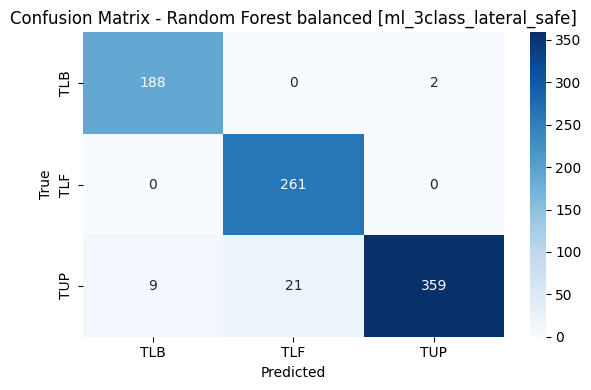


Random Forest TLBx3 [ml_3class_lateral_safe]
Accuracy    : 0.9643
Macro F1    : 0.9660
TLB Recall  : 0.9842
TLB F1      : 0.9765
TLB Prec    : 0.9689

              precision    recall  f1-score   support

         TLB       0.97      0.98      0.98       190
         TLF       0.93      1.00      0.96       261
         TUP       0.99      0.93      0.96       389

    accuracy                           0.96       840
   macro avg       0.96      0.97      0.97       840
weighted avg       0.97      0.96      0.96       840



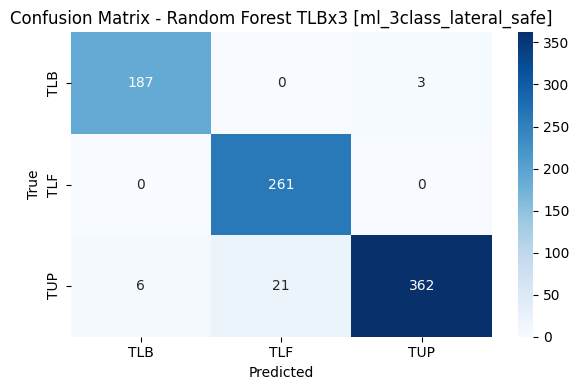


Random Forest TLBx4.5 [ml_3class_lateral_safe]
Accuracy    : 0.9571
Macro F1    : 0.9584
TLB Recall  : 0.9737
TLB F1      : 0.9635
TLB Prec    : 0.9536

              precision    recall  f1-score   support

         TLB       0.95      0.97      0.96       190
         TLF       0.92      1.00      0.96       261
         TUP       0.99      0.92      0.95       389

    accuracy                           0.96       840
   macro avg       0.95      0.96      0.96       840
weighted avg       0.96      0.96      0.96       840



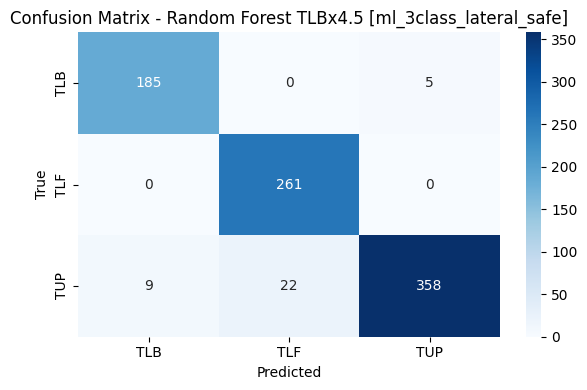


SVM balanced [ml_3class_lateral_safe]
Accuracy    : 0.9667
Macro F1    : 0.9662
TLB Recall  : 0.9947
TLB F1      : 0.9545
TLB Prec    : 0.9175

              precision    recall  f1-score   support

         TLB       0.92      0.99      0.95       190
         TLF       0.96      1.00      0.98       261
         TUP       1.00      0.93      0.96       389

    accuracy                           0.97       840
   macro avg       0.96      0.98      0.97       840
weighted avg       0.97      0.97      0.97       840



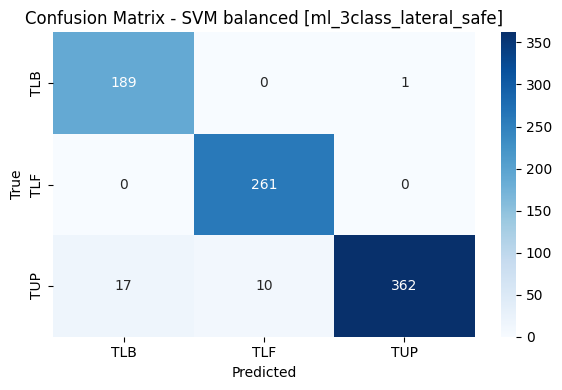


SVM TLBx3 [ml_3class_lateral_safe]
Accuracy    : 0.9548
Macro F1    : 0.9561
TLB Recall  : 0.9947
TLB F1      : 0.9618
TLB Prec    : 0.9310

              precision    recall  f1-score   support

         TLB       0.93      0.99      0.96       190
         TLF       0.92      1.00      0.96       261
         TUP       1.00      0.90      0.95       389

    accuracy                           0.95       840
   macro avg       0.95      0.97      0.96       840
weighted avg       0.96      0.95      0.95       840



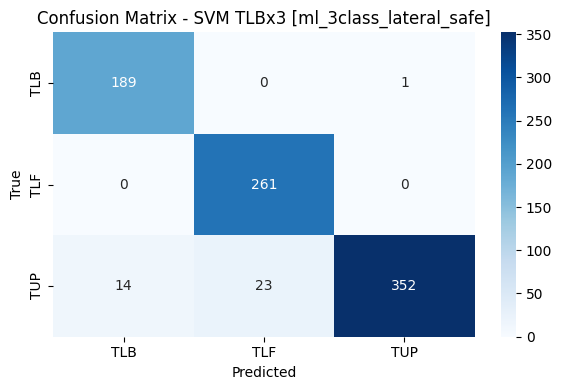


LogReg balanced [ml_3class_lateral_safe]
Accuracy    : 0.9524
Macro F1    : 0.9522
TLB Recall  : 1.0000
TLB F1      : 0.9406
TLB Prec    : 0.8879

              precision    recall  f1-score   support

         TLB       0.89      1.00      0.94       190
         TLF       0.94      1.00      0.97       261
         TUP       1.00      0.90      0.95       389

    accuracy                           0.95       840
   macro avg       0.94      0.97      0.95       840
weighted avg       0.96      0.95      0.95       840



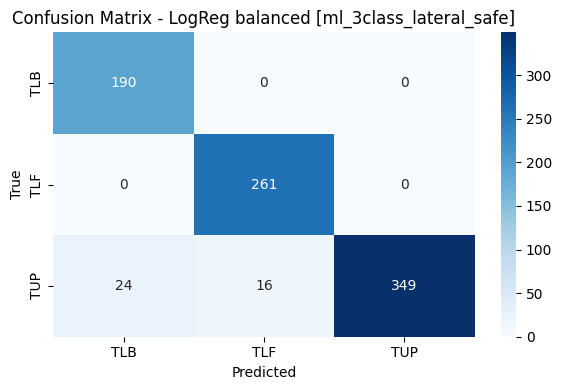


LogReg TLBx4.5 [ml_3class_lateral_safe]
Accuracy    : 0.9405
Macro F1    : 0.9417
TLB Recall  : 1.0000
TLB F1      : 0.9429
TLB Prec    : 0.8920

              precision    recall  f1-score   support

         TLB       0.89      1.00      0.94       190
         TLF       0.91      1.00      0.95       261
         TUP       1.00      0.87      0.93       389

    accuracy                           0.94       840
   macro avg       0.93      0.96      0.94       840
weighted avg       0.95      0.94      0.94       840



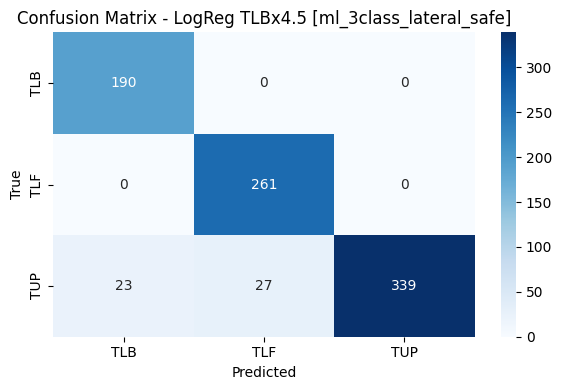


Gradient Boosting [ml_3class_lateral_safe]
Accuracy    : 0.9595
Macro F1    : 0.9618
TLB Recall  : 0.9789
TLB F1      : 0.9764
TLB Prec    : 0.9738

              precision    recall  f1-score   support

         TLB       0.97      0.98      0.98       190
         TLF       0.91      1.00      0.95       261
         TUP       0.99      0.92      0.95       389

    accuracy                           0.96       840
   macro avg       0.96      0.97      0.96       840
weighted avg       0.96      0.96      0.96       840



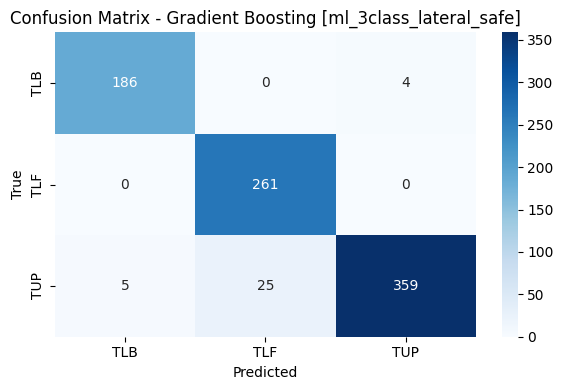


KNN [ml_3class_lateral_safe]
Accuracy    : 0.9369
Macro F1    : 0.9361
TLB Recall  : 0.9000
TLB F1      : 0.9218
TLB Prec    : 0.9448

              precision    recall  f1-score   support

         TLB       0.94      0.90      0.92       190
         TLF       0.92      1.00      0.96       261
         TUP       0.95      0.92      0.93       389

    accuracy                           0.94       840
   macro avg       0.94      0.94      0.94       840
weighted avg       0.94      0.94      0.94       840



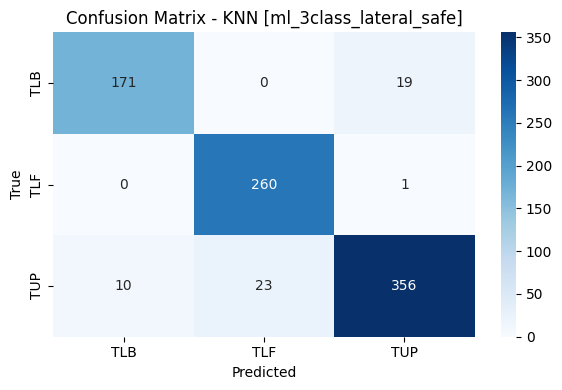


MLP [ml_3class_lateral_safe]
Accuracy    : 0.9452
Macro F1    : 0.9479
TLB Recall  : 0.9842
TLB F1      : 0.9639
TLB Prec    : 0.9444

              precision    recall  f1-score   support

         TLB       0.94      0.98      0.96       190
         TLF       0.89      1.00      0.94       261
         TUP       0.99      0.89      0.94       389

    accuracy                           0.95       840
   macro avg       0.94      0.96      0.95       840
weighted avg       0.95      0.95      0.95       840



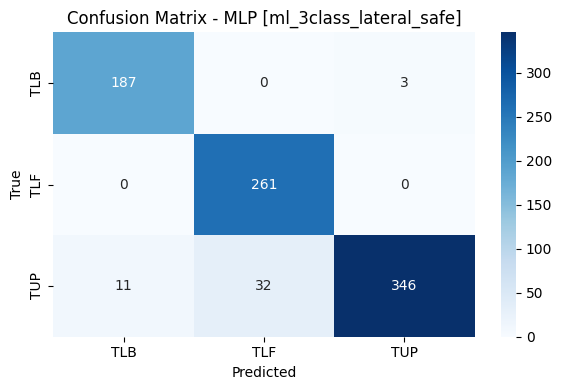

In [ ]:
for feature_set_name, feature_cols in FEATURE_SETS.items():
    print("\n" + "#" * 80)
    print(f"FEATURE SET: {feature_set_name}")
    print("#" * 80)

    X = df_clean[feature_cols].copy().values
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y_enc[train_idx]
    y_test = y_enc[test_idx]

    print(f"Using {len(feature_cols)} features")
    print(feature_cols)

    models = build_models(label_encoder)

    for model_name, model in models.items():
        full_name = f"{model_name} [{feature_set_name}]"

        result = evaluate(
            name=full_name,
            model=model,
            X_tr=X_train,
            y_tr=y_train,
            X_te=X_test,
            y_te=y_test,
            label_encoder=label_encoder
        )

        deploy_score = (
            0.45 * result["tlb_recall"] +
            0.35 * result["tlb_f1"] +
            0.20 * result["macro_f1"]
        )

        results.append({
            "feature_set": feature_set_name,
            "model_name": model_name,
            "full_name": full_name,
            "n_features": len(feature_cols),
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
            "tlb_precision": result["tlb_precision"],
            "tlb_recall": result["tlb_recall"],
            "tlb_f1": result["tlb_f1"],
            "deploy_score": deploy_score,
        })

        trained_models.append({
            "full_name": full_name,
            "model": result["model"],
            "feature_cols": feature_cols,
        })


## Final ranking

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["deploy_score", "tlb_recall", "tlb_f1", "macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("FINAL RANKING:")
print(
    results_df[
        ["full_name", "n_features", "accuracy", "macro_f1", "tlb_recall", "tlb_f1", "deploy_score"]
    ]
)


FINAL RANKING:
                                         full_name  n_features  accuracy  \
0  Random Forest balanced [ml_3class_lateral_safe]           3  0.961905   
1     Random Forest TLBx3 [ml_3class_lateral_safe]           3  0.964286   
2               SVM TLBx3 [ml_3class_lateral_safe]           3  0.954762   
3            SVM balanced [ml_3class_lateral_safe]           3  0.966667   
4       Gradient Boosting [ml_3class_lateral_safe]           3  0.959524   
5                     MLP [ml_3class_lateral_safe]           3  0.945238   
6         LogReg balanced [ml_3class_lateral_safe]           3  0.952381   
7          LogReg TLBx4.5 [ml_3class_lateral_safe]           3  0.940476   
8   Random Forest TLBx4.5 [ml_3class_lateral_safe]           3  0.957143   
9                     KNN [ml_3class_lateral_safe]           3  0.936905   

   macro_f1  tlb_recall    tlb_f1  deploy_score  
0  0.963412    0.989474  0.971576      0.977997  
1  0.966013    0.984211  0.976501      0.977873 

## Best model selection

In [ ]:
results_robust = results_df[
    results_df["feature_set"] == "ml_3class_lateral_safe"
].copy().sort_values(
    by=["deploy_score", "tlb_recall", "tlb_f1", "macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

if results_robust.empty:
    raise ValueError("No robust_3class model found.")

results_robust_nonzero = results_robust[results_robust["tlb_recall"] > 0].copy()
if not results_robust_nonzero.empty:
    results_robust = results_robust_nonzero.reset_index(drop=True)

best_row        = results_robust.iloc[0]
best_model_name = best_row["full_name"]

best_model_entry  = next(m for m in trained_models if m["full_name"] == best_model_name)
best_model        = best_model_entry["model"]
best_feature_cols = best_model_entry["feature_cols"]

print("[DEPLOY MODE: ML 3-CLASS + GEOMETRIC LATERAL]")
print(f"Best model:      {best_model_name}")
print(f"Accuracy:        {best_row['accuracy']:.4f}")
print(f"Macro F1:        {best_row['macro_f1']:.4f}")
print(f"TLB Recall:      {best_row['tlb_recall']:.4f}")
print(f"TLB F1:          {best_row['tlb_f1']:.4f}")
print(f"Deploy score:    {best_row['deploy_score']:.4f}")
print(f"Features ({len(best_feature_cols)}): {best_feature_cols}")
print(f"ML classes:      {list(label_encoder.classes_)}")

print("\nTop 5 models:")
print(
    results_robust.head(5)[
        ["full_name", "accuracy", "macro_f1", "tlb_recall", "tlb_f1", "deploy_score"]
    ]
)

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open("best_feature_columns.pkl", "wb") as f:
    pickle.dump(best_feature_cols, f)

print("\nSaved: best_model.pkl | label_encoder.pkl | best_feature_columns.pkl")

[DEPLOY MODE: ML 3-CLASS + GEOMETRIC LATERAL]
Best model:      Random Forest balanced [ml_3class_lateral_safe]
Accuracy:        0.9619
Macro F1:        0.9634
TLB Recall:      0.9895
TLB F1:          0.9716
Deploy score:    0.9780
Features (3): ['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle']
ML classes:      ['TLB', 'TLF', 'TUP']

Top 5 modelli:
                                         full_name  accuracy  macro_f1  \
0  Random Forest balanced [ml_3class_lateral_safe]  0.961905  0.963412   
1     Random Forest TLBx3 [ml_3class_lateral_safe]  0.964286  0.966013   
2               SVM TLBx3 [ml_3class_lateral_safe]  0.954762  0.956139   
3            SVM balanced [ml_3class_lateral_safe]  0.966667  0.966171   
4       Gradient Boosting [ml_3class_lateral_safe]  0.959524  0.961820   

   tlb_recall    tlb_f1  deploy_score  
0    0.989474  0.971576      0.977997  
1    0.984211  0.976501      0.977873  
2    0.994737  0.961832      0.975501  
3    0.994737  0.9

# 4. Final Model Selection and Real-Time Inference with MediaPipe

In this part of the notebook we complete two key steps of the pipeline:

1. **Final model comparison on group split**
2. **Loading the best model for real-time webcam inference**

The goal is to use the same approach at inference time as during training:
- landmark extraction with **MediaPipe Pose**
- postural feature construction
- normalization with the saved scaler
- posture prediction via the best model
- result visualization on the frame

## Import libraries for webcam and inference

In [29]:
import os
import cv2
import json
import pickle
import collections
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import time
from datetime import datetime
from IPython.display import display

## Loading the saved model

In [ ]:
required_files = ["best_model.pkl", "label_encoder.pkl", "best_feature_columns.pkl"]
missing_files  = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f"Missing files: {missing_files}")
 
with open("best_model.pkl", "rb") as f:
    best_model = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
with open("best_feature_columns.pkl", "rb") as f:
    BEST_FEATURE_COLUMNS = pickle.load(f)
 
print("Model:    ", type(best_model).__name__)
print("Classes:  ", list(label_encoder.classes_))
print("Features: ", BEST_FEATURE_COLUMNS)

Modello:   Pipeline
Classi:    ['TLB', 'TLF', 'TUP']
Features:  ['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle']


## MediaPipe Pose initialization

In [ ]:
mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
 
if "pose" in dir() and pose is not None:
    try:
        pose.close()
    except Exception:
        pass
 
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)
print("MediaPipe Pose initialized.")

MediaPipe Pose inizializzato.


I0000 00:00:1774641323.871535 3293582 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3


## Iphone connection

In [ ]:
CAMERA_INDEX = 1

cap = cv2.VideoCapture(CAMERA_INDEX)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

actual_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
actual_h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

print(f"Acquired resolution: {actual_w}x{actual_h}")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774641323.956560 3293909 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774641323.967374 3293910 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-03-27 20:55:24.090 Python[96454:3293582] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Risoluzione acquisita: 1280.0x720.0


## Main pipeline parameters

In [ ]:
CONF_THRESHOLD     = 0.5
SMOOTH_WINDOW      = 10
CALIBRATION_FRAMES = 30
POSTURE_FRAMES     = 15
REQUIRED_IDX       = [0, 11, 12]

z_buffer = collections.deque(maxlen=SMOOTH_WINDOW)

ALL_POSTURE_CLASSES    = ["TLB", "TLF", "TLL", "TLR", "TUP"]
ML_TARGET_CLASSES      = ["TLB", "TLF", "TUP"]
GEOMETRIC_ONLY_CLASSES = ["TLL", "TLR"]

ML_FEATURE_NAMES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
]

GEOMETRIC_FEATURE_NAMES = [
    "shoulder_slope",
    "shoulder_z_asym",
    "ear_height_asym",
    "head_lateral_ratio",
]

BASELINE_FEATURE_NAMES = [
    "head_y_ratio",
    "head_neck_vertical_angle",
    "trunk_forward_backward_angle",
    "shoulder_slope",
    "shoulder_z_asym",
    "ear_height_asym",
    "head_lateral_ratio",
]

ML_ZSCORE_STD_FLOOR = {
    "head_y_ratio":                 0.05,
    "head_neck_vertical_angle":     4.0,
    "trunk_forward_backward_angle": 4.0,
}

FEATURE_NAMES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    "trunk_forward_backward_angle",
    "shoulder_z_asym",
    "hip_shoulder_lateral",
    "ear_height_asym",
]

LABEL_COLORS = {
    "TUP": (0, 220, 0),
    "TLL": (255, 100, 0),
    "TLR": (255, 100, 0),
    "TLF": (0, 180, 255),
    "TLB": (180, 0, 255),
}
LABEL_DESC = {
    "TUP": "Correct posture",
    "TLL": "Left lateral lean",
    "TLR": "Right lateral lean",
    "TLF": "Forward head / slumping",
    "TLB": "Backward posture",
}

if not set(BEST_FEATURE_COLUMNS).issubset(set(FEATURE_NAMES)):
    print("  BEST_FEATURE_COLUMNS contains features not available at runtime!")
    print("   Missing:", set(BEST_FEATURE_COLUMNS) - set(FEATURE_NAMES))
elif not set(BEST_FEATURE_COLUMNS).issubset(set(ML_FEATURE_NAMES)):
    print("  The model uses features outside the final ML set!")
    print("   BEST_FEATURE_COLUMNS:", BEST_FEATURE_COLUMNS)
    print("   ML_FEATURE_NAMES:   ", ML_FEATURE_NAMES)
else:
    print(f"✓  ML feature columns aligned — {len(BEST_FEATURE_COLUMNS)} features.")
    print("   ML feature columns:", BEST_FEATURE_COLUMNS)

✓  ML feature columns allineate — 3 feature.
   ML feature columns: ['head_y_ratio', 'head_neck_vertical_angle', 'trunk_forward_backward_angle']


## Preprocessing and feature extraction functions

In [ ]:
def capture_frames_batch(n_frames):
    frames = []
    for _ in range(n_frames):
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        time.sleep(0.12)
    return frames


def landmarks_to_array(results):
    lm = results.pose_world_landmarks.landmark
    return np.array([[l.x, l.y, l.z] for l in lm], dtype=float)


def smooth_z(lm_array):
    z_buffer.append(lm_array[:, 2].copy())
    smoothed = lm_array.copy()
    smoothed[:, 2] = np.mean(z_buffer, axis=0)
    return smoothed


def check_visibility(results):
    lm = results.pose_landmarks.landmark
    shoulders_ok = (lm[11].visibility >= CONF_THRESHOLD and
                    lm[12].visibility >= CONF_THRESHOLD)
    head_ok = ((lm[2].visibility >= CONF_THRESHOLD and
                lm[5].visibility >= CONF_THRESHOLD) or
               (lm[7].visibility >= CONF_THRESHOLD and
                lm[8].visibility >= CONF_THRESHOLD) or
               lm[0].visibility >= CONF_THRESHOLD)
    return shoulders_ok and head_ok


def extract_features_from_array(lm_array, results):
    lm = results.pose_landmarks.landmark

    features_dict, control_dict = extract_features_with_control(
        nose=lm_array[0],
        l_eye=lm_array[2],  r_eye=lm_array[5],
        l_ear=lm_array[7],  r_ear=lm_array[8],
        l_shoulder=lm_array[11], r_shoulder=lm_array[12],
        l_hip=lm_array[23],      r_hip=lm_array[24],
        nose_vis=lm[0].visibility,
        l_eye_vis=lm[2].visibility,  r_eye_vis=lm[5].visibility,
        l_ear_vis=lm[7].visibility,  r_ear_vis=lm[8].visibility,
        l_shoulder_vis=lm[11].visibility, r_shoulder_vis=lm[12].visibility,
        l_hip_vis=lm[23].visibility,      r_hip_vis=lm[24].visibility,
    )

    control_dict["shoulders_reliable"] = (lm[11].visibility >= CONF_THRESHOLD and
                                           lm[12].visibility >= CONF_THRESHOLD)
    control_dict["head_reliable"] = (
        (lm[2].visibility >= CONF_THRESHOLD and lm[5].visibility >= CONF_THRESHOLD) or
        (lm[7].visibility >= CONF_THRESHOLD and lm[8].visibility >= CONF_THRESHOLD) or
        lm[0].visibility >= CONF_THRESHOLD
    )
    control_dict["hips_reliable"] = (lm[23].visibility >= CONF_THRESHOLD and
                                      lm[24].visibility >= CONF_THRESHOLD)
    control_dict["trunk_support_reliable"] = control_dict["hips_reliable"]

    return features_dict, control_dict


def feature_dict_to_model_vector(feature_dict, feature_columns):
    return np.array([feature_dict.get(f, np.nan) for f in feature_columns], dtype=float)

def feature_dict_to_ml_vector(feature_dict, feature_columns, baseline_stats):
    """
    Transform live features into z-scores relative to the user's baseline,
    using the same std floor chosen during training.
    """
    vec = []
    for f in feature_columns:
        val = feature_dict.get(f, np.nan)

        if f in baseline_stats:
            b = baseline_stats[f]["median"]
            floor = ML_ZSCORE_STD_FLOOR.get(f, 0.01)
            std = max(baseline_stats[f]["std"], floor)
        else:
            b = np.nan
            std = 1.0

        if np.isfinite(val) and np.isfinite(b):
            vec.append((val - b) / std)
        else:
            vec.append(np.nan)

    return np.array(vec, dtype=float)

## Prediction and classification functions

### Costanti e baseline helpers

_safe_std: during calibration the user might stay almost perfectly still, producing a very low or zero std. This function ensures that each feature always has a minimum "sensitivity" threshold that varies by type: for example head_lateral_ratio is already very sensitive (floor 0.08), while upper_body_inclination requires larger deviations (floor 4.0) before triggering an alert.

_clamped_delta: answers the question: "how far has this feature moved from the calibrated neutral posture?" — in units of standard deviations. The clamp to ±4 prevents an extreme value (e.g. head fully turned) from producing an oversized score that destabilizes the classification.

get_baseline_value: reads the reference value (by default the median) for a feature from the calibrated baseline. Used whenever we need to compare the current posture against the user's neutral posture.

get_baseline_std: reads the user's natural variability for a feature from the baseline. Used to determine how much a feature needs to deviate to be considered "anomalous" compared to how that person normally moves.

In [35]:
EPS_STD = 1e-3

STD_FLOOR = {
    "head_y_ratio":                 0.05,
    "head_neck_vertical_angle":     4.0,
    "trunk_forward_backward_angle": 4.0,
    "shoulder_slope":               4.0,
    "shoulder_z_asym":              0.20,
    "ear_height_asym":              0.06,
    "head_lateral_ratio":           0.10,
}

DELTA_CLAMP = 4.0
HYSTERESIS  = 0.15
TUP_FLOOR   = 1.0

def _safe_std(std, feature_name):
    floor = STD_FLOOR.get(feature_name, 0.001)
    return max(std, floor) if (np.isfinite(std) and std > 0) else floor

def _clamped_delta(val, baseline, std):
    if not (np.isfinite(val) and np.isfinite(baseline) and
            np.isfinite(std) and std > EPS_STD):
        return np.nan
    return float(np.clip((val - baseline) / std, -DELTA_CLAMP, DELTA_CLAMP))

def get_baseline_value(baseline_stats, name, field="median"):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get(field, np.nan)

def get_baseline_std(baseline_stats, name):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get("std", np.nan)


### Predict and score helpers

predict: passes the feature vector to the trained ML model and returns the predicted class (e.g. "TLF"), its probability, and all per-class probabilities. This is the point where the model "votes" on the current posture.

_compute_lateral_score: measures how much the user is leaning laterally compared to their calibrated neutral posture, combining two signals: horizontal head displacement (head_lateral_ratio, higher weight) and torso inclination (upper_body_inclination, lower weight). A positive value indicates a left lean (TLL), negative indicates a right lean (TLR).

_compute_sagittal_score: measures how much the user is leaning forward or backward compared to their calibrated neutral posture, combining three signals: trunk depth inclination (trunk_forward_backward_angle, primary weight), relative head height with respect to the shoulders (head_y_ratio), and the head-neck angle (head_neck_vertical_angle, used only as reinforcement when it agrees with the other two). A negative value indicates forward posture (TLF), positive indicates backward posture (TLB).

In [ ]:
LAT_SIGN = +1
SLOPE_SIGN = +1  

def predict(features_vector, model, label_encoder):
    fv    = np.asarray(features_vector, dtype=float).reshape(1, -1)
    probs = model.predict_proba(fv)[0]
    idx   = int(np.argmax(probs))
    return label_encoder.inverse_transform([idx])[0], float(probs[idx]), probs

def _feature_delta(feat, baseline_stats, name):
    val = feat.get(name, np.nan)
    if not np.isfinite(val):
        return np.nan

    b   = get_baseline_value(baseline_stats, name)
    std = _safe_std(get_baseline_std(baseline_stats, name), name)
    return _clamped_delta(val, b, std)

def _aligned_support(d, sign_ref, min_abs):
    if not np.isfinite(d):
        return np.nan
    if abs(d) < min_abs:
        return 0.0
    return abs(d) if np.sign(d) == np.sign(sign_ref) else 0.0

def _compute_lateral_score(feat, baseline_stats):
    """
    More conservative lateral geometry:
    - shoulder_slope = primary driver
    - shoulder_z_asym = confirmation
    - ear_height_asym = backup
    - head_lateral_ratio = very weak support
    """
    d_slope = _feature_delta(feat, baseline_stats, "shoulder_slope")
    if np.isfinite(d_slope):
        d_slope *= SLOPE_SIGN

    d_sz = _feature_delta(feat, baseline_stats, "shoulder_z_asym")
    if np.isfinite(d_sz):
        d_sz *= LAT_SIGN

    d_ear = _feature_delta(feat, baseline_stats, "ear_height_asym")
    d_hlr = _feature_delta(feat, baseline_stats, "head_lateral_ratio")

    # direction: prefer slope, use shoulder_z_asym only as fallback
    if np.isfinite(d_slope) and abs(d_slope) >= 0.75:
        direction_signal = d_slope
    elif np.isfinite(d_sz) and abs(d_sz) >= 1.00:
        direction_signal = d_sz
    else:
        return np.nan

    sign_ref = np.sign(direction_signal)
    if sign_ref == 0:
        return np.nan

    slope_mag = abs(d_slope) if np.isfinite(d_slope) else 0.0
    sz_mag    = _aligned_support(d_sz,  sign_ref, min_abs=0.50)
    ear_mag   = _aligned_support(d_ear, sign_ref, min_abs=0.50)
    hlr_mag   = _aligned_support(d_hlr, sign_ref, min_abs=0.75)

    n_confirms = sum([
        int(np.isfinite(sz_mag)  and sz_mag  > 0),
        int(np.isfinite(ear_mag) and ear_mag > 0),
    ])
    if slope_mag < 1.25 and n_confirms == 0:
        return np.nan

    components = []
    if slope_mag > 0:
        components.append((slope_mag, 3.0))
    if np.isfinite(sz_mag) and sz_mag > 0:
        components.append((sz_mag, 1.2))
    if np.isfinite(ear_mag) and ear_mag > 0:
        components.append((ear_mag, 0.8))
    if np.isfinite(hlr_mag) and hlr_mag > 0:
        components.append((hlr_mag, 0.25))

    if not components:
        return np.nan

    total_w = sum(w for _, w in components)
    mag = sum(v * w for v, w in components) / total_w
    return float(sign_ref * mag)

def _compute_sagittal_score(feat, baseline_stats):
    """
    Sagittal score:
    - trunk_forward_backward_angle and head_y_ratio are the drivers
    - head_neck_vertical_angle is only a weak forward reinforcement
    """
    tfb_d = _feature_delta(feat, baseline_stats, "trunk_forward_backward_angle")
    hyr_d = _feature_delta(feat, baseline_stats, "head_y_ratio")
    hnv_d = _feature_delta(feat, baseline_stats, "head_neck_vertical_angle")

    components = []

    if np.isfinite(tfb_d):
        components.append((tfb_d, 3.0))

    if np.isfinite(hyr_d):
        components.append((hyr_d, 2.0))

    forward_supported = (
        (np.isfinite(tfb_d) and tfb_d < -0.5) or
        (np.isfinite(hyr_d) and hyr_d < -0.5)
    )

    if np.isfinite(hnv_d) and hnv_d > 0.75 and forward_supported:
        components.append((-hnv_d, 0.5))

    if not components:
        return np.nan

    total_w = sum(w for _, w in components)
    return float(sum(v * w for v, w in components) / total_w)

### Classify posture

classify_posture: this is the core of the classification system. It takes the ML model's prediction and "corrects" or "confirms" it using geometric rules based on the calibrated baseline. The idea is that ML alone can fail in edge cases, so geometric rules act as a safeguard.

1. Extreme lateral guard (lat_abs > 3.5)
If the head is displaced laterally by a very large amount, the geometric rule overrides the ML without even checking its confidence. The case is so obvious that trusting the model is unnecessary.
2. High-confidence ML (confidence >= 0.85)
If the model is very confident in its prediction, no intervention is applied. Geometric rules only kick in when the ML is uncertain.
3. Geometric TLR (head_tilt < -30° and head_shoulder_alignment < -15°)
Detects the specific case where the user is filmed from the side and the head appears rotated/tilted in an extreme way — a situation where the ML tends to get confused but the geometry is clear.
4. Geometric TLF (hnv > baseline + 8° and hyr < baseline - 0.08)
Detects the head dropping forward: the neck-vertical angle has increased relative to the baseline and the head has dropped relative to the shoulders. This block does not trigger if there is also a strong lateral lean (to avoid false TLF when the user is simply leaning sideways).
5. No signal (lat_sig = False and sag_sig = False)
If neither the lateral nor the sagittal signal exceeds the threshold, the posture is considered correct (TUP) regardless of what the ML says.
6. Strong lateral
If the lateral signal clearly exceeds the threshold, TLL or TLR is returned based on the sign of the score.
7. Lateral dominates sagittal
If both signals are present but the lateral one is at least 1.1x stronger than the sagittal one, the lateral wins. This prevents a small sagittal component from changing the classification when lateral lean is the main issue.
8. Sagittal only
If there is only a sagittal signal with no relevant lateral component, TLF (forward) or TLB (backward) is returned based on the sign.
9. Ambiguous case
If no rule has produced a clear answer, the ML prediction is used as a fallback.

In [ ]:
def classify_posture(label_ml, confidence, feature_dict, baseline_stats,
                     current_label="TUP"):
    """
    Final hybrid classifier:
    - TLL / TLR from geometry
    - TLB from sagittal (with ML support when available)
    - TUP / TLF primarily from ML
    - protection against:
        1) lateral being misclassified as TLF
        2) frames with strong sagittal ending up as lateral
    """

    LAT_ABS_THR_ENTER = 2.20
    DOMINANCE_RATIO   = 1.20
    HYSTERESIS_RATIO  = 1.0 - HYSTERESIS

    SAG_FORWARD_LOCK  = 1.30
    SAG_BACKWARD_LOCK = 1.00

    BACKWARD_PRIORITY_THR  = 2.00
    BACKWARD_LAT_RATIO_MAX = 1.20

    FORWARD_PRIORITY_THR   = 1.60
    FORWARD_LAT_RATIO_MAX  = 1.25

    LATERAL_OVERRIDE_ABS   = 3.35
    LATERAL_OVERRIDE_RATIO = 1.45

    lat_score = _compute_lateral_score(feature_dict, baseline_stats)
    sag_score = _compute_sagittal_score(feature_dict, baseline_stats)

    lat_abs = abs(lat_score) if np.isfinite(lat_score) else 0.0
    sag_abs = abs(sag_score) if np.isfinite(sag_score) else 0.0

    lat_exit = LAT_ABS_THR_ENTER * HYSTERESIS_RATIO
    eff_lat_thr = lat_exit if current_label in ("TLL", "TLR") else LAT_ABS_THR_ENTER
    lat_sig = lat_abs > eff_lat_thr

    strong_forward = np.isfinite(sag_score) and sag_score < -SAG_FORWARD_LOCK
    strong_backward = np.isfinite(sag_score) and sag_score > SAG_BACKWARD_LOCK

    backward_priority = (
        np.isfinite(sag_score) and
        sag_score > BACKWARD_PRIORITY_THR and
        (not np.isfinite(lat_score) or lat_abs <= sag_abs * BACKWARD_LAT_RATIO_MAX)
    )

    forward_priority = (
        np.isfinite(sag_score) and
        sag_score < -FORWARD_PRIORITY_THR and
        (not np.isfinite(lat_score) or lat_abs <= sag_abs * FORWARD_LAT_RATIO_MAX)
    )

    lateral_override = (
        np.isfinite(lat_score) and
        lat_abs >= max(LATERAL_OVERRIDE_ABS, sag_abs * LATERAL_OVERRIDE_RATIO)
    )

    info = {
        "lateral_score":   round(float(lat_score), 4) if np.isfinite(lat_score) else None,
        "sagittal_score":  round(float(sag_score), 4) if np.isfinite(sag_score) else None,
        "eff_lat_thr":     round(eff_lat_thr, 3),
        "eff_sag_thr":     None,
        "rule_triggered":  False,
        "confidence_tier": "high",
        "reason":          [],
    }

    # 1) Strong backward: should win over lateral unless lateral is truly dominant
    if backward_priority:
        if label_ml == "TLB":
            info["reason"].append("backward priority + ML(TLB)")
            return "TLB", info
        info["reason"].append("backward priority -> TLB")
        return "TLB", info

    # 2) Strong forward: should win over lateral unless lateral is truly dominant
    if forward_priority:
        if label_ml == "TLF":
            info["reason"].append("forward priority + ML(TLF)")
            return "TLF", info
        info["reason"].append("forward priority -> TLF")
        return "TLF", info

    # 3) Truly dominant lateral: can override sagittal
    if lateral_override:
        info["rule_triggered"] = True
        direction = "TLL" if lat_score > 0 else "TLR"
        info["reason"].append(f"dominant lateral override ({lat_abs:.2f})")
        return direction, info

    # 4) Standard sagittal lock
    if strong_backward and not lat_sig:
        if label_ml == "TLB":
            info["reason"].append("strong sagittal + ML(TLB)")
            return "TLB", info
        info["reason"].append("sagittal lock -> TLB")
        return "TLB", info

    if strong_forward and not lat_sig:
        if label_ml == "TLF":
            info["reason"].append("strong sagittal + ML(TLF)")
            return "TLF", info
        info["reason"].append("sagittal lock -> TLF")
        return "TLF", info

    # 5) Lateral hold, but not if sagittal is clearly strong
    if current_label == "TLL" and np.isfinite(lat_score) and lat_score > 0:
        if lat_abs > lat_exit and not backward_priority and not forward_priority:
            info["reason"].append(f"TLL hold (lat={lat_abs:.2f})")
            return "TLL", info

    if current_label == "TLR" and np.isfinite(lat_score) and lat_score < 0:
        if lat_abs > lat_exit and not backward_priority and not forward_priority:
            info["reason"].append(f"TLR hold (lat={lat_abs:.2f})")
            return "TLR", info

    # 6) Normal lateral: only if dominant over sagittal
    if lat_sig and lat_abs > max(TUP_FLOOR + 0.25, sag_abs * DOMINANCE_RATIO):
        info["rule_triggered"] = True
        direction = "TLL" if lat_score > 0 else "TLR"
        info["reason"].append(f"geometric lateral ({lat_abs:.2f})")
        return direction, info

    # 7) ML on non-lateral classes
    if label_ml in ML_TARGET_CLASSES:
        info["reason"].append(f"ML 3-class ({label_ml})")
        return label_ml, info

    # 8) Final fallback
    if np.isfinite(sag_score):
        if sag_score > TUP_FLOOR:
            info["reason"].append("sagittal fallback -> TLB")
            return "TLB", info
        if sag_score < -TUP_FLOOR:
            info["reason"].append("sagittal fallback -> TLF")
            return "TLF", info

    info["reason"].append("fallback -> TUP")
    return "TUP", info

## Drawing functions for the debug overlay

In [ ]:
GREEN  = (0, 220, 0)
YELLOW = (0, 220, 255)
ORANGE = (0, 140, 255)
RED    = (0, 0, 255)
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
CYAN   = (255, 220, 0)
GRAY   = (180, 180, 180)
 
 
def draw_landmark_point(frame, lm, idx, color, radius=6):
    h, w = frame.shape[:2]
    x = int(lm[idx].x * w)
    y = int(lm[idx].y * h)
    cv2.circle(frame, (x, y), radius, color, -1)
    cv2.circle(frame, (x, y), radius + 2, WHITE, 1)
    return (x, y)
 
 
def draw_line_between(frame, p1, p2, color, thickness=2):
    cv2.line(frame, p1, p2, color, thickness)
 
 
def put_text_pro(frame, text, pos, scale=0.7, color=WHITE, thickness=1):
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, BLACK, thickness + 2, cv2.LINE_AA)
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, color, thickness, cv2.LINE_AA)
 
 
def draw_debug_overlay(frame, lm, feature_dict, label, confidence,
                        confidence_tier="high", rule_info=None):
    h, w   = frame.shape[:2]
    color  = LABEL_COLORS.get(label, WHITE)
    desc   = LABEL_DESC.get(label, label)
 
    # Barra superiore
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, 80), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)
 
    put_text_pro(frame, f"{label}  {desc}", (14, 30),
                 scale=0.85, color=color, thickness=2)
    put_text_pro(frame, f"Conf: {confidence:.1%}", (14, 56),
                 scale=0.55, color=GRAY, thickness=1)
 
    if rule_info and rule_info.get("reason"):
        reason_str = " | ".join(rule_info["reason"])[:60]
        put_text_pro(frame, reason_str, (14, 74),
                     scale=0.38, color=YELLOW, thickness=1)
 
    bar_color = GREEN if label == "TUP" else RED
    cv2.rectangle(frame, (w - 10, 0), (w, h), bar_color, -1)
 
    p_leye = draw_landmark_point(frame, lm, 2, CYAN)
    p_reye = draw_landmark_point(frame, lm, 5, CYAN)
    draw_line_between(frame, p_leye, p_reye, CYAN, 2)
    draw_landmark_point(frame, lm, 7, (180, 180, 0))
    draw_landmark_point(frame, lm, 8, (180, 180, 0))
    p_nose = draw_landmark_point(frame, lm, 0, WHITE, 5)
    p_lsho = draw_landmark_point(frame, lm, 11, GREEN)
    p_rsho = draw_landmark_point(frame, lm, 12, GREEN)
    draw_line_between(frame, p_lsho, p_rsho, GREEN, 2)
 
    mid_sho = ((p_lsho[0] + p_rsho[0]) // 2, (p_lsho[1] + p_rsho[1]) // 2)
    cv2.circle(frame, mid_sho, 5, WHITE, -1)
    draw_line_between(frame, p_nose, mid_sho, ORANGE, 2)
 
    mid_eye = ((p_leye[0] + p_reye[0]) // 2, (p_leye[1] + p_reye[1]) // 2)
    draw_line_between(frame, mid_eye, mid_sho, YELLOW, 2)
 
    if label != "TUP":
        bx, by = w // 2, h // 2
        ov2 = frame.copy()
        cv2.rectangle(ov2, (bx - 160, by - 35), (bx + 160, by + 35), (10, 10, 10), -1)
        cv2.addWeighted(ov2, 0.8, frame, 0.2, 0, frame)
        cv2.rectangle(frame, (bx - 160, by - 35), (bx + 160, by + 35), color, 2)
        put_text_pro(frame, f"CORRECT: {desc}",
                     (bx - 148, by + 10), scale=0.6, color=color, thickness=1)
 
    return frame

## Calibration + Loop

FASE 1: CALIBRAZIONE
Siediti in postura corretta e tieni la posizione.
  Frame candidato valido 1/60
  Frame candidato valido 2/60
  Frame candidato valido 3/60
  Frame candidato valido 4/60
  Frame candidato valido 5/60
  Frame candidato valido 6/60
  Frame candidato valido 7/60
  Frame candidato valido 8/60
  Frame candidato valido 9/60
  Frame candidato valido 10/60
  Frame candidato valido 11/60
  Frame candidato valido 12/60
  Frame candidato valido 13/60
  Frame candidato valido 14/60
  Frame candidato valido 15/60
  Frame candidato valido 16/60
  Frame candidato valido 17/60
  Frame candidato valido 18/60
  Frame candidato valido 19/60
  Frame candidato valido 20/60
  Frame candidato valido 21/60
  Frame candidato valido 22/60
  Frame candidato valido 23/60
  Frame candidato valido 24/60
  Frame candidato valido 25/60
  Frame candidato valido 26/60
  Frame candidato valido 27/60
  Frame candidato valido 28/60
  Frame candidato valido 29/60
  Frame candidato valido 30/60
  Frame 

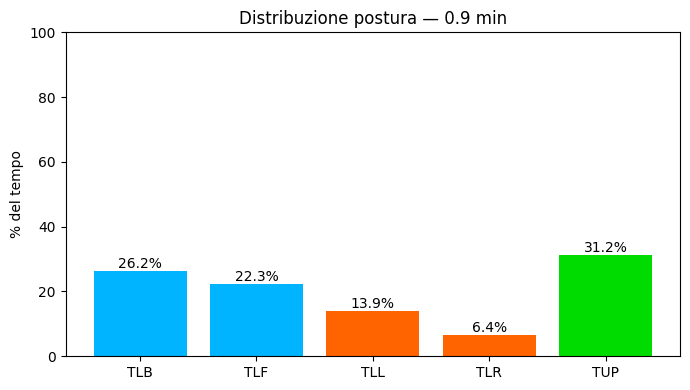


✓ Grafico salvato in: Test/report_sessione.png
✓ Log salvato: Test/monitor_20260327_205641.json


In [ ]:
import collections, time, json, os, warnings
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
CALIBRATION_FRAMES           = globals().get("CALIBRATION_FRAMES", 20)
CALIBRATION_CANDIDATE_FACTOR = globals().get("CALIBRATION_CANDIDATE_FACTOR", 2)
CLASSIFICATION_FPS           = globals().get("CLASSIFICATION_FPS", 4)
ALERT_SECONDS                = globals().get("ALERT_SECONDS", 4.0)
ALERT_BUFFER_SIZE            = int(ALERT_SECONDS * CLASSIFICATION_FPS)
WINDOW_NAME                  = globals().get("WINDOW_NAME", "Posture Monitor")
TEST_DIR                     = globals().get("TEST_DIR", "Test")
os.makedirs(TEST_DIR, exist_ok=True)

SHADOW_MODE            = True
SHADOW_HIGH_CONF_THR   = 0.80

ALERT_BAD_RATIO_ON     = 0.70
ALERT_BAD_RATIO_OFF    = 0.40
ALERT_DOMINANCE_MIN    = 0.55
ALERT_COOLDOWN_SEC     = 4.0

CALIB_MAX_FRAME_DEV      = 3.5
CALIB_MAX_TOTAL_DEV      = 10.0
CALIB_MIN_VALID_FEATURES = max(4, int(0.70 * len(BASELINE_FEATURE_NAMES)))
CALIB_MIN_KEEP_RATIO     = 0.60

DISPLAY_LABELS = {
    "TUP": "Upright posture",
    "TLF": "Trunk forward",
    "TLB": "Trunk backward",
    "TLL": "Trunk lateral left",
    "TLR": "Trunk lateral right",
    "NA":  "N/A",
}

FONT_TITLE = cv2.FONT_HERSHEY_TRIPLEX
FONT_SUB   = cv2.FONT_HERSHEY_COMPLEX
FONT_PANEL = cv2.FONT_HERSHEY_DUPLEX

HEADER_BG   = (248, 248, 248)
HEADER_TEXT = (25, 25, 25)

ALERT_BG     = (40, 40, 230)
ALERT_BORDER = (255, 255, 255)
ALERT_TEXT   = (255, 255, 255)

FINAL_SCALE = 0.92
FINAL_THICK = 2
SUB_SCALE   = 0.54
SUB_THICK   = 1

def _rounded_box(img, x1, y1, x2, y2, color, radius=16, thickness=-1):
    radius = int(max(4, min(radius, (x2 - x1) // 6, (y2 - y1) // 6)))

    if thickness < 0:
        cv2.rectangle(img, (x1 + radius, y1), (x2 - radius, y2), color, -1)
        cv2.rectangle(img, (x1, y1 + radius), (x2, y2 - radius), color, -1)
        cv2.circle(img, (x1 + radius, y1 + radius), radius, color, -1)
        cv2.circle(img, (x2 - radius, y1 + radius), radius, color, -1)
        cv2.circle(img, (x1 + radius, y2 - radius), radius, color, -1)
        cv2.circle(img, (x2 - radius, y2 - radius), radius, color, -1)
    else:
        cv2.line(img, (x1 + radius, y1), (x2 - radius, y1), color, thickness)
        cv2.line(img, (x1 + radius, y2), (x2 - radius, y2), color, thickness)
        cv2.line(img, (x1, y1 + radius), (x1, y2 - radius), color, thickness)
        cv2.line(img, (x2, y1 + radius), (x2, y2 - radius), color, thickness)
        cv2.ellipse(img, (x1 + radius, y1 + radius), (radius, radius), 180, 0, 90, color, thickness)
        cv2.ellipse(img, (x2 - radius, y1 + radius), (radius, radius), 270, 0, 90, color, thickness)
        cv2.ellipse(img, (x1 + radius, y2 - radius), (radius, radius), 90, 0, 90, color, thickness)
        cv2.ellipse(img, (x2 - radius, y2 - radius), (radius, radius), 0, 0, 90, color, thickness)


def _draw_center_panel(frame, title, lines, panel_w=760):
    img = frame.copy()
    h, w = img.shape[:2]

    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (w, h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.30, img, 0.70, 0, img)

    panel_h = 130 + 42 * len(lines)
    x1 = max(20, (w - panel_w) // 2)
    y1 = max(20, (h - panel_h) // 2)
    x2 = min(w - 20, x1 + panel_w)
    y2 = min(h - 20, y1 + panel_h)

    _rounded_box(img, x1, y1, x2, y2, (255, 255, 255), radius=22, thickness=-1)
    _rounded_box(img, x1, y1, x2, y2, (70, 70, 70), radius=22, thickness=2)

    cv2.putText(
        img, title, (x1 + 34, y1 + 52),
        FONT_TITLE, 1.10, (20, 20, 20), 2, cv2.LINE_AA
    )

    yy = y1 + 100
    for line in lines:
        color = (35, 35, 35)
        scale = 0.72
        thick = 1

        if "Press Q to exit" in line:
            color = (0, 0, 220)
            scale = 0.74
            thick = 2

        cv2.putText(
            img, line, (x1 + 34, yy),
            FONT_PANEL, scale, color, thick, cv2.LINE_AA
        )
        yy += 40

    return img


def _show_panel_loop(title, lines_fn, seconds, cap, window_name):
    end_t = time.time() + seconds
    while time.time() < end_t:
        ret, frame = cap.read()
        if not ret or frame is None:
            frame = np.zeros((720, 1280, 3), dtype=np.uint8)

        disp = _draw_center_panel(frame, title, lines_fn(max(0.0, end_t - time.time())))
        cv2.imshow(window_name, disp)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            raise KeyboardInterrupt


# ── Pre-check ────────────────────────────────────────────────────────────────
if cap is None:
    raise RuntimeError("Camera not initialized.")
if pose is None:
    raise RuntimeError("MediaPipe pose not initialized.")

z_buffer.clear()
baseline_stats = None

cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(WINDOW_NAME, 1280, 720)

# ═══════════════════════════════════════════════════════════════════
# PHASE 1 — LIVE CALIBRATION
# ═══════════════════════════════════════════════════════════════════
print("=" * 60)
print("PHASE 1: CALIBRATION")
print("Sit in correct posture and hold the position.")
print("=" * 60)

try:
    _show_panel_loop(
        "Calibration",
        lambda rem: [
            "Stay in upright posture looking forward",
            f"Starting in {int(np.ceil(rem))} s",
            "Press Q to exit",
        ],
        5.0,
        cap,
        WINDOW_NAME
    )

    target_candidates = CALIBRATION_FRAMES * CALIBRATION_CANDIDATE_FACTOR
    calib_candidates = []
    last_sample_time = 0.0

    while len(calib_candidates) < target_candidates:
        ret, frame = cap.read()
        if not ret or frame is None:
            continue

        now = time.time()

        if now - last_sample_time >= 1.0 / CLASSIFICATION_FPS:
            last_sample_time = now

            try:
                res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            except Exception:
                res = None

            if res and res.pose_landmarks and res.pose_world_landmarks and check_visibility(res):
                lm_arr = smooth_z(landmarks_to_array(res))
                fd, _ = extract_features_from_array(lm_arr, res)

                mv = feature_dict_to_model_vector(fd, BEST_FEATURE_COLUMNS)
                if not np.all(~np.isfinite(mv)):
                    calib_candidates.append(fd)
                    print(f"  Valid candidate frame {len(calib_candidates)}/{target_candidates}")

        disp = _draw_center_panel(
            frame,
            "Calibration",
            [
                "Stay in upright posture looking forward",
                f"Frames collected: {len(calib_candidates)}/{target_candidates}        Final frames used: {CALIBRATION_FRAMES}",
                "Press Q to exit",
            ],
        )
        cv2.imshow(WINDOW_NAME, disp)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            raise KeyboardInterrupt

    if len(calib_candidates) < max(CALIBRATION_FRAMES, CALIBRATION_FRAMES // 2):
        raise RuntimeError("Calibration failed — too few valid frames.")

    calib_df = pd.DataFrame(calib_candidates)

    for name in BASELINE_FEATURE_NAMES:
        if name not in calib_df.columns:
            calib_df[name] = np.nan
        calib_df[name] = pd.to_numeric(calib_df[name], errors="coerce")

    valid_feature_count = calib_df[BASELINE_FEATURE_NAMES].notna().sum(axis=1)
    calib_df = calib_df.loc[valid_feature_count >= CALIB_MIN_VALID_FEATURES].copy()

    if len(calib_df) < max(CALIBRATION_FRAMES // 2, 10):
        raise RuntimeError("Calibration failed — too many incomplete frames.")

    robust_center = {}
    robust_scale = {}

    for name in BASELINE_FEATURE_NAMES:
        vals = calib_df[name].dropna().values.astype(float)
        if len(vals) == 0:
            robust_center[name] = np.nan
            robust_scale[name] = np.nan
            continue

        med = np.median(vals)
        mad = np.median(np.abs(vals - med))
        robust_center[name] = med
        robust_scale[name] = 1.4826 * mad if mad > 1e-9 else max(np.std(vals), 1e-6)

    per_feature_dev = pd.DataFrame(index=calib_df.index)

    for name in BASELINE_FEATURE_NAMES:
        med = robust_center[name]
        scale = robust_scale[name]

        if not np.isfinite(med) or not np.isfinite(scale) or scale <= 0:
            per_feature_dev[name] = np.nan
            continue

        per_feature_dev[name] = (calib_df[name] - med).abs() / scale

    frame_dev_mean = per_feature_dev.clip(upper=8.0).mean(axis=1, skipna=True)
    frame_dev_max  = per_feature_dev.max(axis=1, skipna=True)

    stable_mask = (
        (frame_dev_mean <= CALIB_MAX_TOTAL_DEV / max(len(BASELINE_FEATURE_NAMES), 1)) &
        ((frame_dev_max <= CALIB_MAX_FRAME_DEV) | frame_dev_max.isna())
    )

    stable_df = calib_df.loc[stable_mask].copy()

    min_keep = max(int(CALIBRATION_FRAMES * CALIB_MIN_KEEP_RATIO), CALIBRATION_FRAMES // 2)
    if len(stable_df) < min_keep:
        ranked_idx = frame_dev_mean.sort_values().index
        stable_df = calib_df.loc[ranked_idx[:max(CALIBRATION_FRAMES, min_keep)]].copy()

    if len(stable_df) > CALIBRATION_FRAMES:
        ranked_idx = frame_dev_mean.loc[stable_df.index].sort_values().index
        stable_df = stable_df.loc[ranked_idx[:CALIBRATION_FRAMES]].copy()

    calib_collected = stable_df.to_dict(orient="records")

    if len(calib_collected) < max(CALIBRATION_FRAMES // 2, 10):
        raise RuntimeError("Calibration failed — too few stable frames after filtering.")

    baseline_stats = {}
    for name in BASELINE_FEATURE_NAMES:
        vals = np.array([d.get(name, np.nan) for d in calib_collected], dtype=float)
        valid = vals[np.isfinite(vals)]
        if len(valid) == 0:
            baseline_stats[name] = {"median": np.nan, "mean": np.nan, "std": np.nan}
        else:
            baseline_stats[name] = {
                "median": float(np.median(valid)),
                "mean":   float(np.mean(valid)),
                "std":    float(np.std(valid)),
            }

    print("\n--- Baseline decision features (median ± std) ---")
    for name in BASELINE_FEATURE_NAMES:
        m = baseline_stats[name]["median"]
        s = baseline_stats[name]["std"]
        ms = f"{m:.4f}" if np.isfinite(m) else "NaN"
        ss = f"{s:.4f}" if np.isfinite(s) else "NaN"
        print(f"  {name:<30} {ms}  ±{ss}")

    sz_baseline = get_baseline_value(baseline_stats, "shoulder_z_asym")
    if np.isfinite(sz_baseline):
        LAT_SIGN = +1 if sz_baseline <= 0 else -1
        print(f"\n── LAT_SIGN calibration ──")
        print(f"  shoulder_z_asym baseline: {sz_baseline:.4f}")
        print(f"  LAT_SIGN set to: {LAT_SIGN}")
    else:
        print("\n⚠ shoulder_z_asym NaN — LAT_SIGN not calibrated, keeping default.")

    print("\n── SLOPE_SIGN check ──")
    print("  Lean LEFT: if the system shows TLR instead of TLL, set SLOPE_SIGN = -1.")

    print("\n--- Key feature diagnostics ---")
    hy_med   = get_baseline_value(baseline_stats, "head_y_ratio")
    hnv_med  = get_baseline_value(baseline_stats, "head_neck_vertical_angle")
    tfba_med = get_baseline_value(baseline_stats, "trunk_forward_backward_angle")
    ss_med   = get_baseline_value(baseline_stats, "shoulder_slope")
    sz_med   = get_baseline_value(baseline_stats, "shoulder_z_asym")
    eh_med   = get_baseline_value(baseline_stats, "ear_height_asym")
    hlr_med  = get_baseline_value(baseline_stats, "head_lateral_ratio")

    print(f"  head_y_ratio baseline               : {hy_med:.4f}")
    print(f"  head_neck_vertical_angle baseline   : {hnv_med:.4f}")
    print(f"  trunk_forward_backward_angle        : {tfba_med:.4f}")
    print(f"  shoulder_slope baseline             : {ss_med:.4f}")
    print(f"  shoulder_z_asym baseline            : {sz_med:.4f}")
    print(f"  ear_height_asym baseline            : {eh_med:.4f}")
    print(f"  head_lateral_ratio baseline         : {hlr_med:.4f}")

    qualita_ok = True
    STD_WARN = {
        "head_y_ratio":                 0.05,
        "head_neck_vertical_angle":     4.0,
        "trunk_forward_backward_angle": 4.0,
        "shoulder_slope":               3.0,
        "shoulder_z_asym":              0.15,
        "ear_height_asym":              0.05,
        "head_lateral_ratio":           0.05,
    }

    print("\n--- Baseline quality check ---")
    for name, threshold in STD_WARN.items():
        s = get_baseline_std(baseline_stats, name)
        if np.isfinite(s) and s > threshold:
            print(f"  ⚠ {name}: std={s:.4f} > {threshold} — noisy baseline, consider re-running.")
            qualita_ok = False

    mean_dev_final = float(frame_dev_mean.loc[stable_df.index].mean()) if len(stable_df) else np.nan
    max_dev_final  = float(frame_dev_max.loc[stable_df.index].mean()) if len(stable_df) else np.nan
    print(f"\n--- Calibration frame stability ---")
    print(f"  Mean deviation of selected frames: {mean_dev_final:.3f}")
    print(f"  Mean max deviation of selected:    {max_dev_final:.3f}")

    if qualita_ok:
        print("  ✓ Stable baseline — ready to proceed.")

    _show_panel_loop(
        "Calibration",
        lambda rem: [
            "Calibration completed",
            "Starting monitoring...",
        ],
        1.2,
        cap,
        WINDOW_NAME
    )

except KeyboardInterrupt:
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    raise RuntimeError("Calibration interrupted by user.")

print("\n✓ Calibration completed.")
print("→ Starting monitoring.")

# ═══════════════════════════════════════════════════════════════════
# PHASE 2 — CONTINUOUS LOOP + TEMPORAL ALERT
# ═══════════════════════════════════════════════════════════════════
posture_buffer         = collections.deque(maxlen=ALERT_BUFFER_SIZE)
session_counts_final   = {cls: 0 for cls in ALL_POSTURE_CLASSES}
session_counts_ml      = {cls: 0 for cls in ALL_POSTURE_CLASSES}

alert_active           = False
alert_label            = None
alert_start_time       = None
last_alert_emit_time   = 0.0
alert_count            = 0
current_bad_ratio      = 0.0
current_bad_majority   = None

bad_posture_secs       = 0.0
total_frames           = 0
session_start          = time.time()
last_clf_time          = 0.0
loop_log               = []

shadow_total           = 0
shadow_agree           = 0
shadow_high_conf_disagree = []

current_label          = "TUP"
current_pred_geom      = "TUP"
current_final_pred     = "TUP"
current_ml_label       = "NA"
current_ml_conf        = 0.0
current_rule           = {
    "confidence_tier": "high",
    "reason":          [],
    "lateral_score":   None,
    "sagittal_score":  None,
    "eff_lat_thr":     None,
    "eff_sag_thr":     None,
}
last_lm = None

print("Monitoring active — press Q on the window to stop.")
print("ML in SHADOW MODE: 3-class (TLB/TLF/TUP). TLL/TLR remain geometric.")
print(f"{'t':>7}  {'change':<16}  {'geom':<4}  {'ml(sh)':<14}  {'sag':>7}  {'lat':>7}  {'thr_s':>6}  {'thr_l':>6}  rule")
print("─" * 105)

try:
    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            break

        now = time.time()

        if now - last_clf_time >= 1.0 / CLASSIFICATION_FPS:
            last_clf_time = now
            try:
                res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            except Exception:
                res = None

            if res and res.pose_landmarks and check_visibility(res):
                last_lm = res.pose_landmarks.landmark
                lm_arr  = smooth_z(landmarks_to_array(res))
                fd, _   = extract_features_from_array(lm_arr, res)
                mv      = feature_dict_to_ml_vector(fd, BEST_FEATURE_COLUMNS, baseline_stats)

                if not np.all(~np.isfinite(mv)):
                    lml, conf, _ = predict(mv, best_model, label_encoder)

                    pred_geom, rule = classify_posture(
                        lml,
                        -1.0 if SHADOW_MODE else conf,
                        fd,
                        baseline_stats,
                        current_label=current_label
                    )

                    final_pred = pred_geom
                    ml_agrees  = (lml == final_pred)

                    if final_pred != current_label:
                        sag    = rule.get("sagittal_score", "?")
                        lat    = rule.get("lateral_score",  "?")
                        thr_s  = rule.get("eff_sag_thr", "?")
                        thr_l  = rule.get("eff_lat_thr", "?")
                        reason = " | ".join(rule.get("reason", []))[:32]
                        t      = now - session_start
                        print(f"  {t:5.1f}s  "
                              f"{current_label} → {final_pred:<4}  "
                              f"{pred_geom:<4}  "
                              f"{lml} {conf:>5.1%}  "
                              f"sag={sag!s:>6}  lat={lat!s:>6}  "
                              f"ts={thr_s!s:>5}  tl={thr_l!s:>5}  {reason}")

                    current_label      = final_pred
                    current_pred_geom  = pred_geom
                    current_final_pred = final_pred
                    current_ml_label   = lml
                    current_ml_conf    = conf
                    current_rule       = rule

                    posture_buffer.append(final_pred)
                    session_counts_final[final_pred] = session_counts_final.get(final_pred, 0) + 1
                    session_counts_ml[lml]           = session_counts_ml.get(lml, 0) + 1
                    total_frames += 1

                    shadow_total += 1
                    shadow_agree += int(ml_agrees)

                    if (not ml_agrees) and conf >= SHADOW_HIGH_CONF_THR:
                        shadow_high_conf_disagree.append({
                            "t":          round(now - session_start, 1),
                            "ml":         lml,
                            "ml_conf":    round(conf, 3),
                            "pred_geom":  pred_geom,
                            "final_pred": final_pred,
                            "reason":     " | ".join(rule.get("reason", [])),
                            "lat_score":  rule.get("lateral_score"),
                            "sag_score":  rule.get("sagittal_score"),
                        })

                    if len(posture_buffer) == ALERT_BUFFER_SIZE:
                        bad = [l for l in posture_buffer if l != "TUP"]
                        current_bad_ratio = len(bad) / ALERT_BUFFER_SIZE

                        if bad:
                            bad_counter = collections.Counter(bad)
                            current_bad_majority, current_bad_majority_count = bad_counter.most_common(1)[0]
                            current_bad_majority_ratio = current_bad_majority_count / len(bad)
                        else:
                            current_bad_majority = None
                            current_bad_majority_ratio = 0.0

                        should_alert = (
                            current_bad_ratio >= ALERT_BAD_RATIO_ON and
                            current_bad_majority is not None and
                            current_bad_majority_ratio >= ALERT_DOMINANCE_MIN
                        )

                        if should_alert:
                            if not alert_active:
                                alert_active = True
                                alert_label = current_bad_majority
                                alert_start_time = now
                                alert_count += 1

                                if now - last_alert_emit_time >= ALERT_COOLDOWN_SEC:
                                    print(
                                        f"⚠ ALERT: {alert_label} — "
                                        f"{LABEL_DESC.get(alert_label, '')} "
                                        f"({current_bad_ratio*100:.0f}% BAD in the last {ALERT_SECONDS:.0f}s)"
                                    )
                                    last_alert_emit_time = now
                            else:
                                if current_bad_majority_ratio >= ALERT_DOMINANCE_MIN:
                                    alert_label = current_bad_majority
                        else:
                            if alert_active and current_bad_ratio <= ALERT_BAD_RATIO_OFF:
                                bad_posture_secs += now - alert_start_time
                                print(
                                    f"✓ ALERT OFF — "
                                    f"BAD {current_bad_ratio*100:.0f}% in the last {ALERT_SECONDS:.0f}s"
                                )
                                alert_active = False
                                alert_label = None
                                alert_start_time = None
                    else:
                        current_bad_ratio = 0.0
                        current_bad_majority = None

                    loop_log.append({
                        "t":              round(now - session_start, 1),
                        "pred_geom":      pred_geom,
                        "final_pred":     final_pred,
                        "label_ml":       lml,
                        "confidence":     round(conf, 3),
                        "ml_agrees":      ml_agrees,
                        "rule_triggered": rule.get("rule_triggered"),
                        "reason":         " | ".join(rule.get("reason", [])),
                        "lat_score":      rule.get("lateral_score"),
                        "sag_score":      rule.get("sagittal_score"),
                        "eff_lat_thr":    rule.get("eff_lat_thr"),
                        "eff_sag_thr":    rule.get("eff_sag_thr"),
                        "alert_active":   alert_active,
                        "alert_label":    alert_label,
                        "bad_ratio":      round(current_bad_ratio, 3),
                        "bad_majority":   current_bad_majority,
                        **{
                            k: round(v, 4) if isinstance(v, float) and np.isfinite(v) else None
                            for k, v in fd.items()
                        },
                    })

        display = frame.copy()
        h, w = display.shape[:2]

        final_desc = DISPLAY_LABELS.get(current_final_pred, current_final_pred)
        geom_desc  = DISPLAY_LABELS.get(current_pred_geom, current_pred_geom)
        ml_desc    = DISPLAY_LABELS.get(current_ml_label, current_ml_label)

        color = LABEL_COLORS.get(current_final_pred, (255, 255, 255))

        # white header attached to borders
        cv2.rectangle(display, (0, 0), (w, 112), HEADER_BG, -1)

        final_line = f"{current_final_pred} - {final_desc}"
        cv2.putText(display, final_line,
                    (22, 42), FONT_TITLE, FINAL_SCALE,
                    color, 2, cv2.LINE_AA)

        geom_line = f"Geom: {current_pred_geom} - {geom_desc}"
        cv2.putText(display, geom_line,
                    (22, 82), FONT_SUB, SUB_SCALE,
                    HEADER_TEXT, SUB_THICK, cv2.LINE_AA)

        ml_line = f"ML: {current_ml_label} - {ml_desc} ({current_ml_conf:.0%})"
        (text_w, _), _ = cv2.getTextSize(ml_line, FONT_SUB, SUB_SCALE, SUB_THICK)
        ml_x = max(22, w - text_w - 24)
        cv2.putText(display, ml_line,
                    (ml_x, 82), FONT_SUB, SUB_SCALE,
                    HEADER_TEXT, SUB_THICK, cv2.LINE_AA)

        # status side bar
        bar_col = (0, 220, 0) if current_final_pred == "TUP" else (0, 0, 255)
        cv2.rectangle(display, (w - 18, 0), (w, h), bar_col, -1)

        # centered red alert banner
        if alert_active and alert_label is not None:
            alert_desc = DISPLAY_LABELS.get(alert_label, alert_label)
            line1 = "!  Posture not correct"
            line2 = f"{alert_label} - {alert_desc}"

            box_w = min(560, w - 140)
            box_h = 108
            x1 = (w - box_w) // 2
            y1 = (h - box_h) // 2
            x2 = x1 + box_w
            y2 = y1 + box_h

            _rounded_box(display, x1, y1, x2, y2, ALERT_BG, radius=18, thickness=-1)
            _rounded_box(display, x1, y1, x2, y2, ALERT_BORDER, radius=18, thickness=1)

            (tw1, _), _ = cv2.getTextSize(line1, FONT_TITLE, 0.78, 2)
            (tw2, _), _ = cv2.getTextSize(line2, FONT_SUB, 0.72, 2)

            tx1 = x1 + (box_w - tw1) // 2
            tx2 = x1 + (box_w - tw2) // 2

            cv2.putText(display, line1,
                        (tx1, y1 + 42), FONT_TITLE, 0.78,
                        ALERT_TEXT, 2, cv2.LINE_AA)
            cv2.putText(display, line2,
                        (tx2, y1 + 82), FONT_SUB, 0.72,
                        ALERT_TEXT, 2, cv2.LINE_AA)

        # landmarks
        if last_lm:
            for idx, col in [(2,  (255, 220, 0)),
                             (5,  (255, 220, 0)),
                             (11, (0, 220, 0)),
                             (12, (0, 220, 0)),
                             (0,  (255, 255, 255))]:
                px = int(last_lm[idx].x * w)
                py = int(last_lm[idx].y * h)
                cv2.circle(display, (px, py), 6, col, -1)
                cv2.circle(display, (px, py), 8, (255, 255, 255), 1)

        cv2.imshow(WINDOW_NAME, display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Monitoring stopped.")
            cv2.destroyAllWindows()
            cv2.waitKey(1)
            break

finally:
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    if alert_active and alert_start_time:
        bad_posture_secs += time.time() - alert_start_time

# ═══════════════════════════════════════════════════════════════════
# FINAL REPORT
# ═══════════════════════════════════════════════════════════════════
total_time = time.time() - session_start
good_time  = max(0.0, total_time - bad_posture_secs)

print("\n" + "═" * 60)
print("SESSION REPORT")
print("═" * 60)
print(f"  Total duration:      {total_time/60:.1f} min ({total_time:.0f}s)")
print(f"  Correct posture:     {good_time:.0f}s  ({good_time/total_time*100:.1f}%)")
print(f"  Incorrect posture:   {bad_posture_secs:.0f}s  ({bad_posture_secs/total_time*100:.1f}%)")
print(f"  Total samples:       {total_frames}")
print(f"  Alerts triggered:    {alert_count}")

if total_frames > 0:
    print("\n  Class distribution (final_pred):")
    for cls in ALL_POSTURE_CLASSES:
        cnt = session_counts_final[cls]
        if cnt > 0:
            pct = cnt / total_frames * 100
            bar = "█" * int(pct / 3)
            print(f"    {cls}  {LABEL_DESC.get(cls, cls):<30} {pct:5.1f}%  {bar}")

if total_frames > 0:
    print("\n  Shadow ML:")
    shadow_agree_pct = shadow_agree / shadow_total * 100 if shadow_total > 0 else 0.0
    print(f"    ML vs final_pred agreement: {shadow_agree}/{shadow_total}  ({shadow_agree_pct:.1f}%)")
    print(f"    High-confidence disagreements (>= {SHADOW_HIGH_CONF_THR:.0%}): {len(shadow_high_conf_disagree)}")

    print("\n  ML class distribution (shadow):")
    for cls in ML_TARGET_CLASSES:
        cnt = session_counts_ml[cls]
        if cnt > 0:
            pct = cnt / total_frames * 100
            bar = "█" * int(pct / 3)
            print(f"    {cls}  {LABEL_DESC.get(cls, cls):<30} {pct:5.1f}%  {bar}")

    if shadow_high_conf_disagree:
        print("\n  High-confidence ML disagreement examples:")
        for row in shadow_high_conf_disagree[:10]:
            print(f"    t={row['t']:>5.1f}s  ML={row['ml']} ({row['ml_conf']:.1%})  "
                  f"GEOM={row['pred_geom']}  FINAL={row['final_pred']}  "
                  f"sag={row['sag_score']}  lat={row['lat_score']}  {row['reason'][:40]}")

if total_frames > 0:
    labels_plot = [c for c in ALL_POSTURE_CLASSES if session_counts_final[c] > 0]
    values_plot = [session_counts_final[c] / total_frames * 100 for c in labels_plot]
    colors_plot = [
        (0/255, 220/255, 0/255)   if l == "TUP" else
        (255/255, 100/255, 0/255) if l in ("TLL", "TLR") else
        (0/255, 180/255, 255/255)
        for l in labels_plot
    ]

    plt.figure(figsize=(7, 4))
    plt.bar(labels_plot, values_plot, color=colors_plot)
    plt.ylabel("% of time")
    plt.title(f"Posture distribution — {total_time/60:.1f} min")
    plt.ylim(0, 100)
    for i, v in enumerate(values_plot):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(TEST_DIR, "report_sessione.png"), dpi=150)
    plt.show()
    print(f"\n✓ Chart saved to: {TEST_DIR}/report_sessione.png")

log_path = os.path.join(
    TEST_DIR, f"monitor_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
)
with open(log_path, "w") as f:
    json.dump({
        "shadow_mode":               SHADOW_MODE,
        "total_seconds":             round(total_time, 1),
        "good_seconds":              round(good_time, 1),
        "bad_seconds":               round(bad_posture_secs, 1),
        "total_frames":              total_frames,
        "alert_seconds":             ALERT_SECONDS,
        "alert_bad_ratio_on":        ALERT_BAD_RATIO_ON,
        "alert_bad_ratio_off":       ALERT_BAD_RATIO_OFF,
        "alert_dominance_min":       ALERT_DOMINANCE_MIN,
        "alert_count":               alert_count,
        "class_counts_final":        session_counts_final,
        "class_counts_ml_shadow":    {k: v for k, v in session_counts_ml.items() if k in ML_TARGET_CLASSES},
        "shadow_agree":              shadow_agree,
        "shadow_total":              shadow_total,
        "shadow_agree_pct":          round((shadow_agree / shadow_total * 100) if shadow_total > 0 else 0.0, 1),
        "shadow_high_conf_thr":      SHADOW_HIGH_CONF_THR,
        "shadow_high_conf_disagree": shadow_high_conf_disagree,
        "log":                       loop_log,
    }, f, indent=2)

print(f"✓ Log saved: {log_path}")

# Connection shutdown

In [ ]:
cap.release()
cv2.destroyAllWindows()
print("Connection closed.")

Connessione chiusa.
